In [1]:
# Importing the basic libraries we will require for the project

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Importing the Machine Learning models we require from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# Importing the other functions we may require from Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# To get diferent metric scores
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,precision_recall_curve,roc_curve,make_scorer

# Code to ignore warnings from function usage
import warnings;
import numpy as np
warnings.filterwarnings('ignore')

In [2]:
traveldata = pd.read_csv('Traveldata_train.csv')
surveydata = pd.read_csv('Surveydata_train.csv')

In [3]:
traveldata.head()

,ID,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins
0,98800001,Female,Loyal Customer,52.0,NaN,Business,272,0.0,5.0
1,98800002,Male,Loyal Customer,48.0,Personal Travel,Eco,2200,9.0,0.0
2,98800003,Female,Loyal Customer,43.0,Business Travel,Business,1061,77.0,119.0
3,98800004,Female,Loyal Customer,44.0,Business Travel,Business,780,13.0,18.0
4,98800005,Female,Loyal Customer,50.0,Business Travel,Business,1981,0.0,0.0


In [4]:
surveydata.head()

,ID,Overall_Experience,Seat_Comfort,Seat_Class,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding
0,98800001,0,Needs Improvement,Green Car,Excellent,Excellent,Very Convenient,Good,Needs Improvement,Acceptable,Needs Improvement,Needs Improvement,Acceptable,Needs Improvement,Good,Needs Improvement,Poor
1,98800002,0,Poor,Ordinary,Excellent,Poor,Needs Improvement,Good,Poor,Good,Good,Excellent,Needs Improvement,Poor,Needs Improvement,Good,Good
2,98800003,1,Needs Improvement,Green Car,Needs Improvement,Needs Improvement,Needs Improvement,Needs Improvement,Good,Excellent,Excellent,Excellent,Excellent,Excellent,Good,Excellent,Excellent
3,98800004,0,Acceptable,Ordinary,Needs Improvement,NaN,Needs Improvement,Acceptable,Needs Improvement,Acceptable,Acceptable,Acceptable,Acceptable,Acceptable,Good,Acceptable,Acceptable
4,98800005,1,Acceptable,Ordinary,Acceptable,Acceptable,Manageable,Needs Improvement,Good,Excellent,Good,Good,Good,Good,Good,Good,Good


In [5]:
print(traveldata.shape)
print(surveydata.shape)

(94379, 9)
(94379, 17)


In [6]:
traveldata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94379 entries, 0 to 94378
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       94379 non-null  int64  
 1   Gender                   94302 non-null  object 
 2   Customer_Type            85428 non-null  object 
 3   Age                      94346 non-null  float64
 4   Type_Travel              85153 non-null  object 
 5   Travel_Class             94379 non-null  object 
 6   Travel_Distance          94379 non-null  int64  
 7   Departure_Delay_in_Mins  94322 non-null  float64
 8   Arrival_Delay_in_Mins    94022 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 6.5+ MB


In [7]:
surveydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94379 entries, 0 to 94378
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       94379 non-null  int64 
 1   Overall_Experience       94379 non-null  int64 
 2   Seat_Comfort             94318 non-null  object
 3   Seat_Class               94379 non-null  object
 4   Arrival_Time_Convenient  85449 non-null  object
 5   Catering                 85638 non-null  object
 6   Platform_Location        94349 non-null  object
 7   Onboard_Wifi_Service     94349 non-null  object
 8   Onboard_Entertainment    94361 non-null  object
 9   Online_Support           94288 non-null  object
 10  Ease_of_Online_Booking   94306 non-null  object
 11  Onboard_Service          86778 non-null  object
 12  Legroom                  94289 non-null  object
 13  Baggage_Handling         94237 non-null  object
 14  CheckIn_Service          94302 non-nul

In [8]:
traveldata.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,94379.0,9.884719e+07,27245.014865,98800001.0,98823595.5,98847190.0,98870784.5,98894379.0
Age,94346.0,3.941965e+01,15.116632,7.0,27.0,40.0,51.0,85.0
Travel_Distance,94379.0,1.978888e+03,1027.961019,50.0,1359.0,1923.0,2538.0,6951.0
Departure_Delay_in_Mins,94322.0,1.464709e+01,38.138781,0.0,0.0,0.0,12.0,1592.0
Arrival_Delay_in_Mins,94022.0,1.500522e+01,38.439409,0.0,0.0,0.0,13.0,1584.0


In [9]:
surveydata.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,94379.0,9.884719e+07,27245.014865,98800001.0,98823595.5,98847190.0,98870784.5,98894379.0
Overall_Experience,94379.0,5.466576e-01,0.497821,0.0,0.0,1.0,1.0,1.0


In [10]:
print(traveldata.duplicated().sum())
print(surveydata.duplicated().sum())

0
0


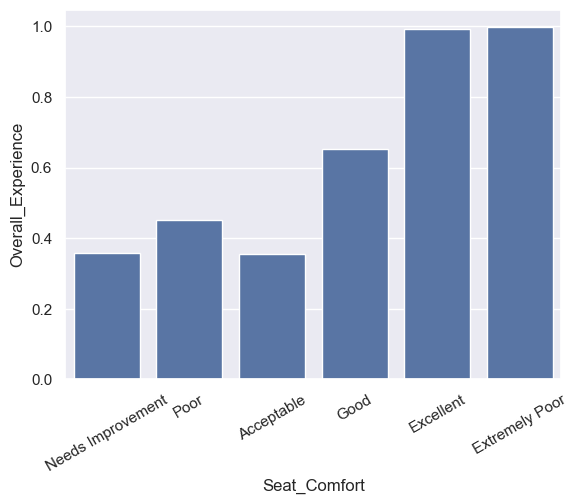

In [11]:
sns.barplot(data = surveydata, x = 'Seat_Comfort', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

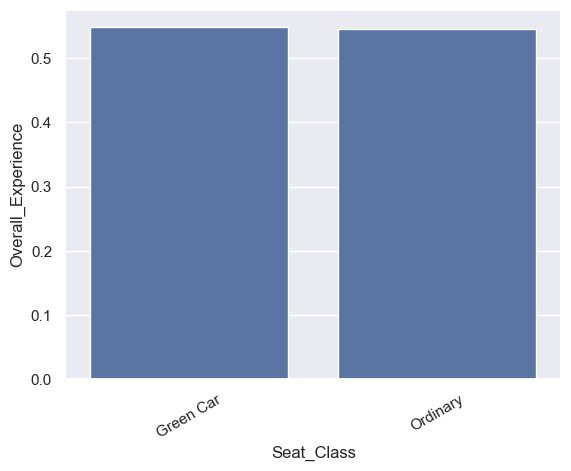

In [12]:
sns.barplot(data = surveydata, x = 'Seat_Class', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

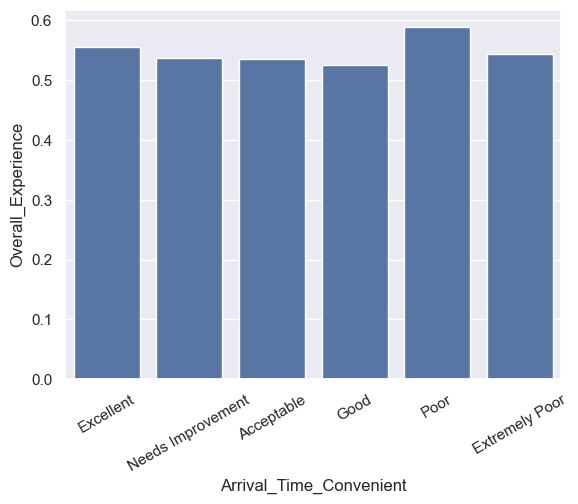

In [13]:
sns.barplot(data = surveydata, x = 'Arrival_Time_Convenient', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

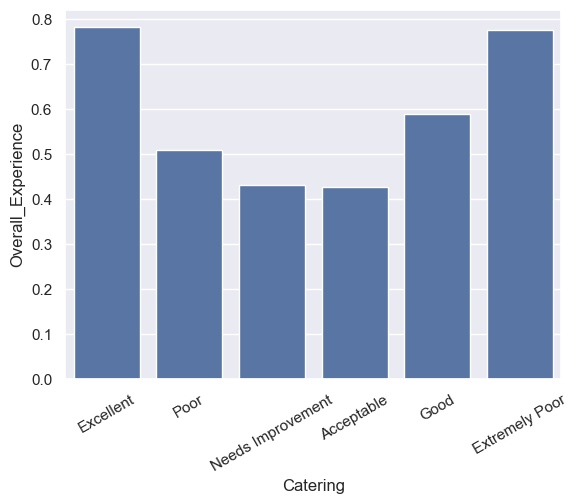

In [14]:
sns.barplot(data = surveydata, x = 'Catering', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

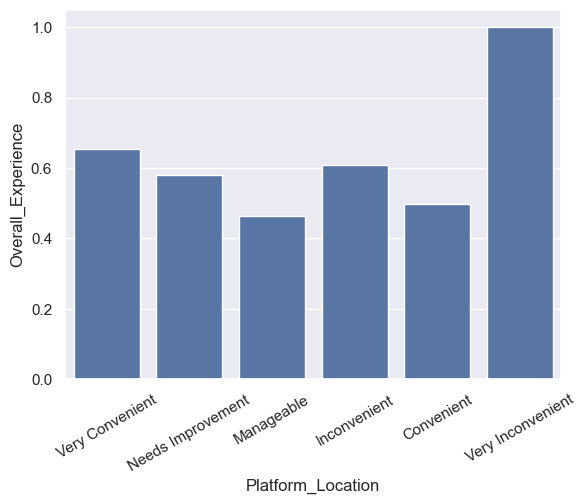

In [15]:
sns.barplot(data = surveydata, x = 'Platform_Location', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

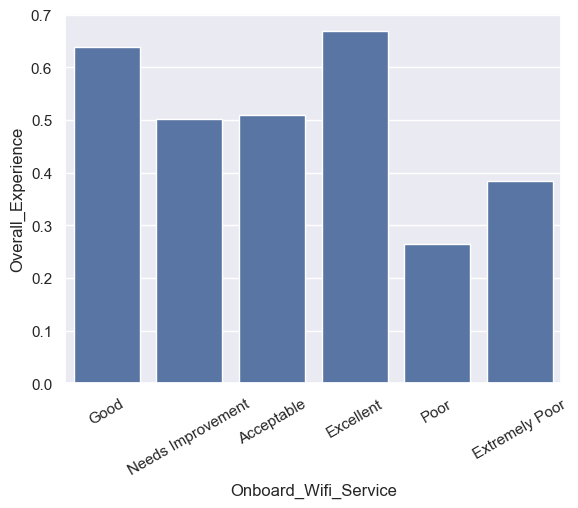

In [16]:
sns.barplot(data = surveydata, x = 'Onboard_Wifi_Service', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

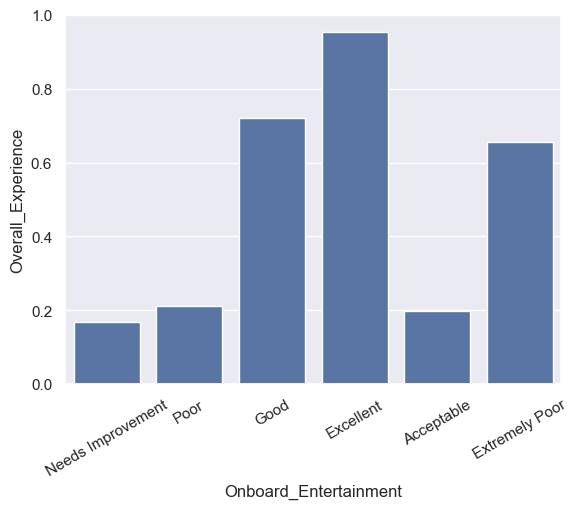

In [17]:
sns.barplot(data = surveydata, x = 'Onboard_Entertainment', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

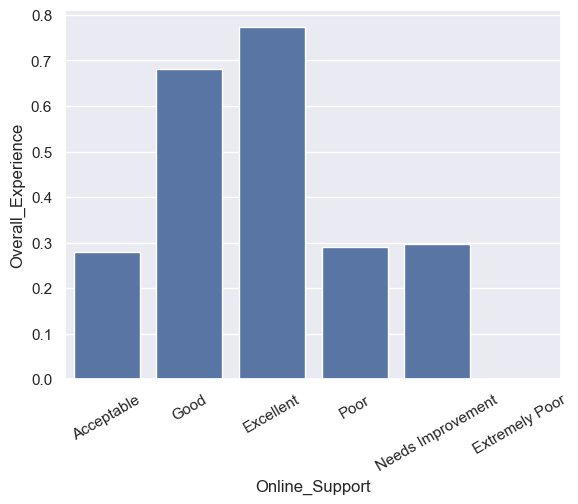

In [18]:
sns.barplot(data = surveydata, x = 'Online_Support', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

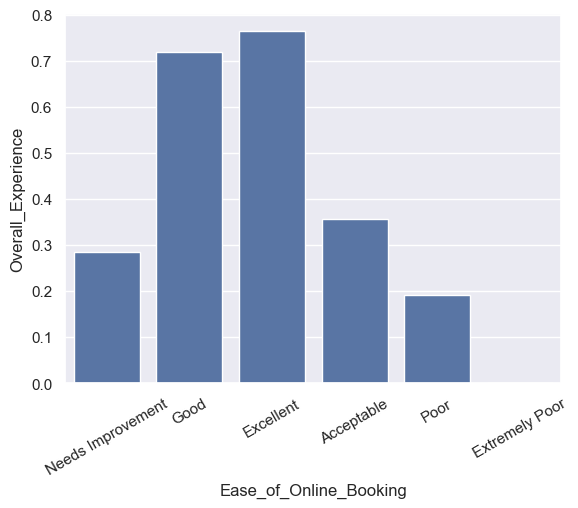

In [19]:
sns.barplot(data = surveydata, x = 'Ease_of_Online_Booking', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

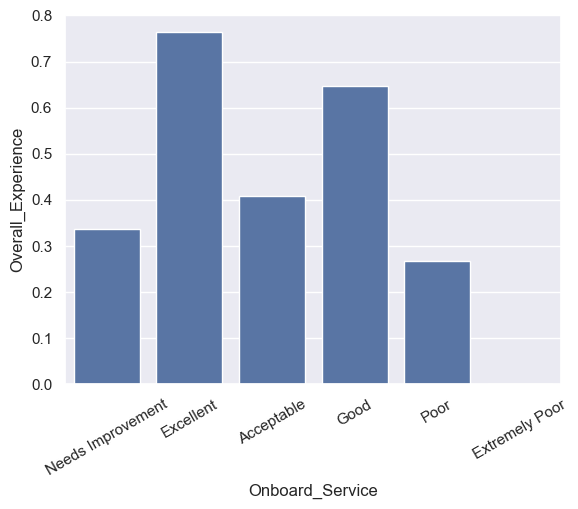

In [20]:
sns.barplot(data = surveydata, x = 'Onboard_Service', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

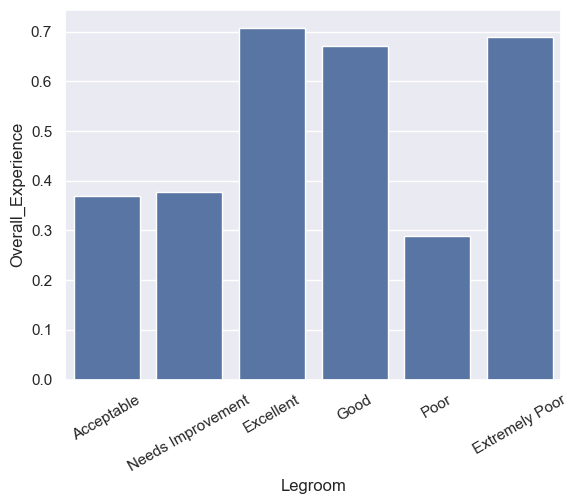

In [21]:
sns.barplot(data = surveydata, x = 'Legroom', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

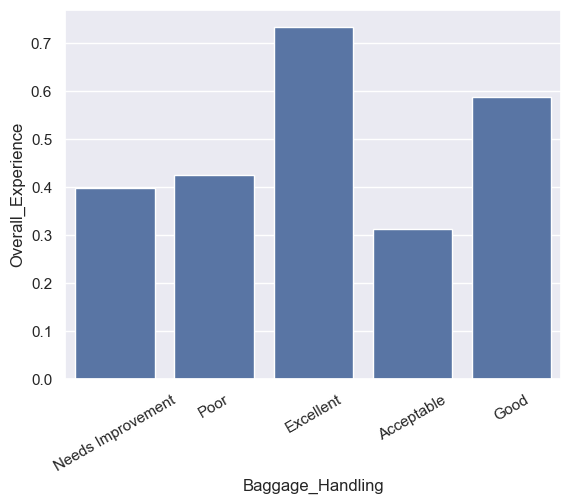

In [22]:
sns.barplot(data = surveydata, x = 'Baggage_Handling', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

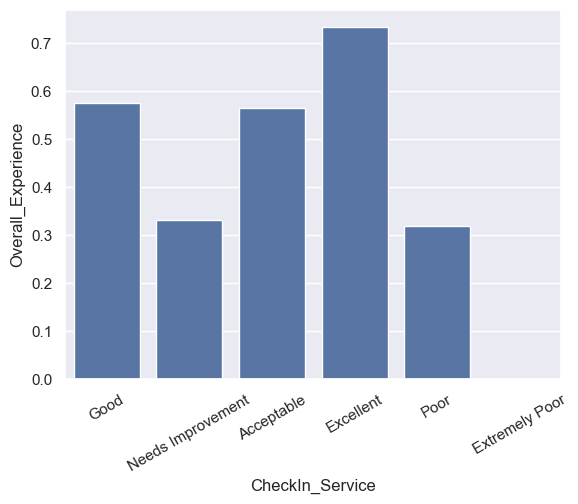

In [23]:
sns.barplot(data = surveydata, x = 'CheckIn_Service', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

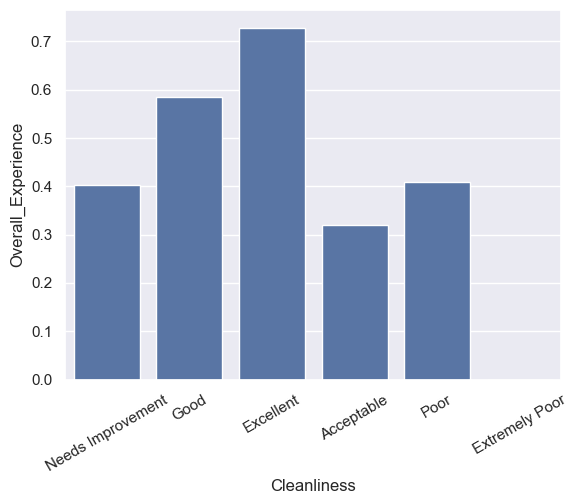

In [24]:
sns.barplot(data = surveydata, x = 'Cleanliness', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

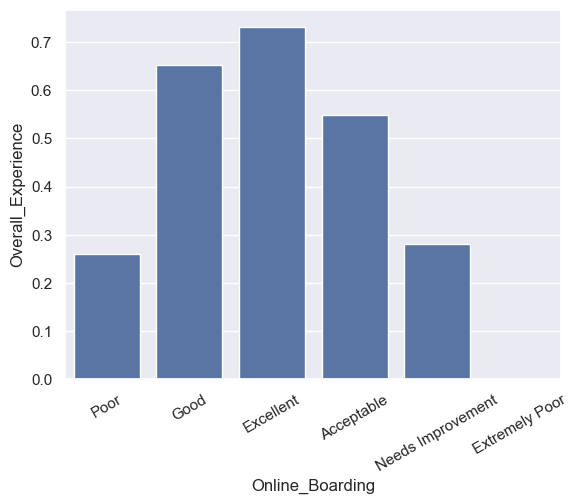

In [25]:
sns.barplot(data = surveydata, x = 'Online_Boarding', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

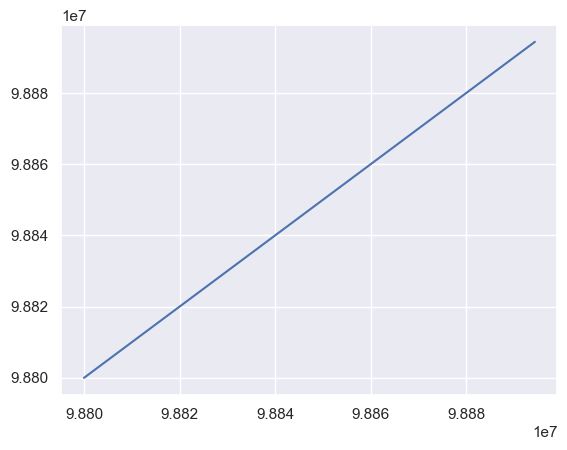

In [26]:
plt.plot(surveydata['ID'], traveldata['ID'])

In [27]:
data = pd.merge(surveydata, traveldata, on='ID')

In [28]:
data 

,ID,Overall_Experience,Seat_Comfort,Seat_Class,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,...,Cleanliness,Online_Boarding,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins
0,98800001,0,Needs Improvement,Green Car,Excellent,Excellent,Very Convenient,Good,Needs Improvement,Acceptable,...,Needs Improvement,Poor,Female,Loyal Customer,52.0,NaN,Business,272,0.0,5.0
1,98800002,0,Poor,Ordinary,Excellent,Poor,Needs Improvement,Good,Poor,Good,...,Good,Good,Male,Loyal Customer,48.0,Personal Travel,Eco,2200,9.0,0.0
2,98800003,1,Needs Improvement,Green Car,Needs Improvement,Needs Improvement,Needs Improvement,Needs Improvement,Good,Excellent,...,Excellent,Excellent,Female,Loyal Customer,43.0,Business Travel,Business,1061,77.0,119.0
3,98800004,0,Acceptable,Ordinary,Needs Improvement,NaN,Needs Improvement,Acceptable,Needs Improvement,Acceptable,...,Acceptable,Acceptable,Female,Loyal Customer,44.0,Business Travel,Business,780,13.0,18.0
4,98800005,1,Acceptable,Ordinary,Acceptable,Acceptable,Manageable,Needs Improvement,Good,Excellent,...,Good,Good,Female,Loyal Customer,50.0,Business Travel,Business,1981,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94374,98894375,0,Poor,Ordinary,Good,Good,Convenient,Poor,Poor,Poor,...,Good,Poor,Male,Loyal Customer,32.0,Business Travel,Business,1357,83.0,125.0
94375,98894376,1,Good,Ordinary,Good,Good,Convenient,Needs Improvement,Excellent,Excellent,...,Acceptable,Good,Male,Loyal Customer,44.0,Business Travel,Business,592,5.0,11.0
94376,98894377,1,Needs Improvement,Green Car,Needs Improvement,Needs Improvement,Needs Improvement,Good,Excellent,Good,...,Good,Acceptable,Male,NaN,63.0,Business Travel,Business,2794,0.0,0.0
94377,98894378,0,Needs Improvement,Ordinary,NaN,Needs Improvement,Convenient,Good,Needs Improvement,Good,...,Excellent,Good,Male,Loyal Customer,16.0,Personal Travel,Eco,2744,0.0,0.0


In [29]:
traveldata.columns.to_list()

['ID',
 'Gender',
 'Customer_Type',
 'Age',
 'Type_Travel',
 'Travel_Class',
 'Travel_Distance',
 'Departure_Delay_in_Mins',
 'Arrival_Delay_in_Mins']

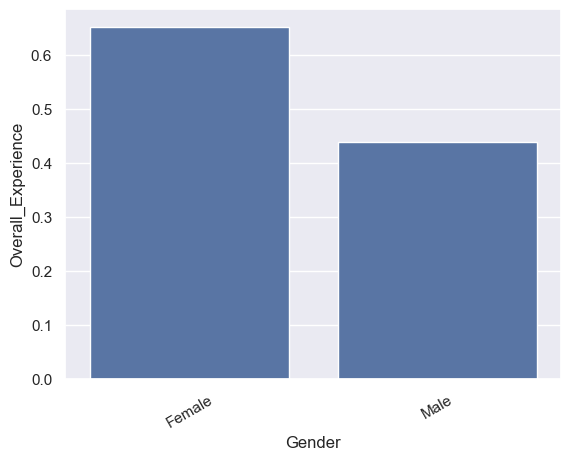

In [30]:
sns.barplot(data = data, x = 'Gender', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

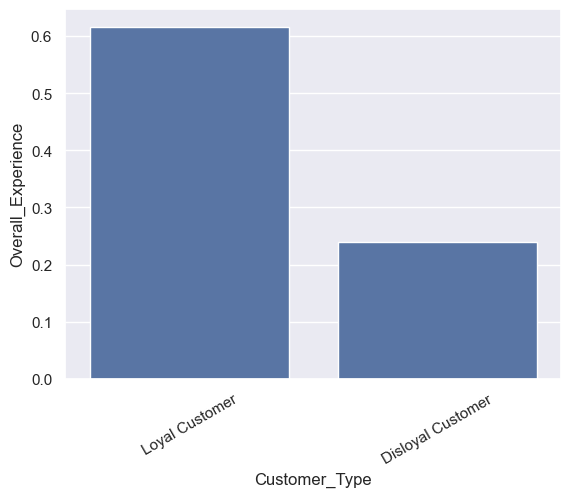

In [31]:
sns.barplot(data = data, x = 'Customer_Type', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

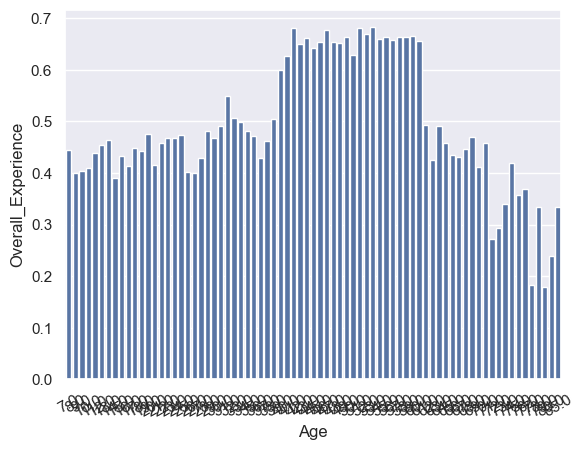

In [32]:
sns.barplot(data = data, x = 'Age', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

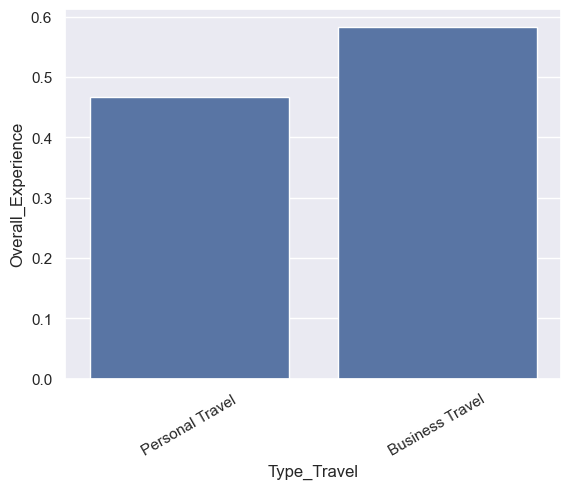

In [33]:
sns.barplot(data = data, x = 'Type_Travel', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

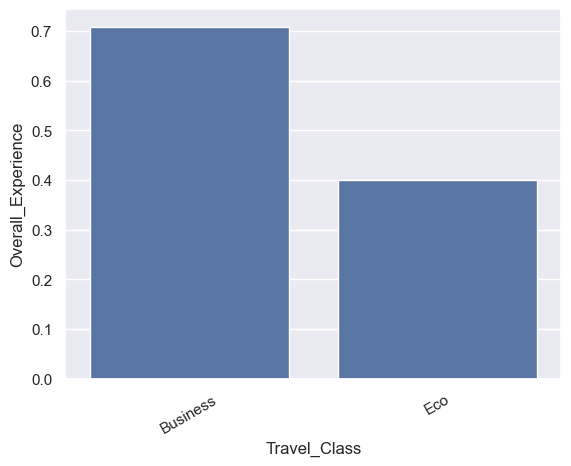

In [34]:
sns.barplot(data = data, x = 'Travel_Class', y = 'Overall_Experience', ci=None)
plt.xticks(rotation=30)
plt.show()

In [35]:
pd.set_option('display.max_info_columns', 50)
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,94379.0,9.884719e+07,27245.014865,98800001.0,98823595.5,98847190.0,98870784.5,98894379.0
Overall_Experience,94379.0,5.466576e-01,0.497821,0.0,0.0,1.0,1.0,1.0
Age,94346.0,3.941965e+01,15.116632,7.0,27.0,40.0,51.0,85.0
Travel_Distance,94379.0,1.978888e+03,1027.961019,50.0,1359.0,1923.0,2538.0,6951.0
Departure_Delay_in_Mins,94322.0,1.464709e+01,38.138781,0.0,0.0,0.0,12.0,1592.0
Arrival_Delay_in_Mins,94022.0,1.500522e+01,38.439409,0.0,0.0,0.0,13.0,1584.0


In [36]:
# Defining the hist_box() function
def hist_box(data, col):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': (0.15, 0.85)}, figsize=(12, 6))
    # Adding a graph in each part
    sns.boxplot(data=data, x=col, ax=ax_box, showmeans=True)
    sns.histplot(data=data, x=col, kde=True, ax=ax_hist)
    plt.show()

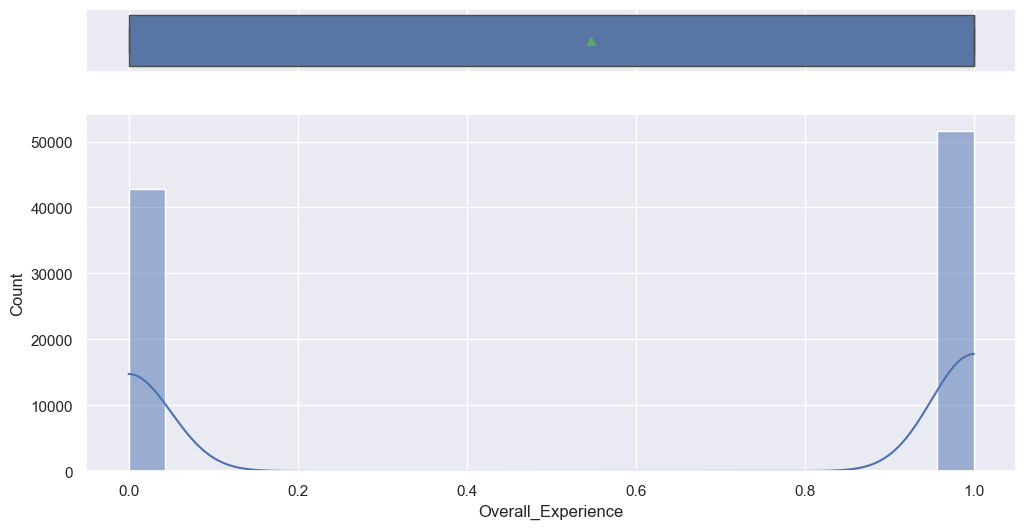

In [37]:
hist_box(data, 'Overall_Experience')

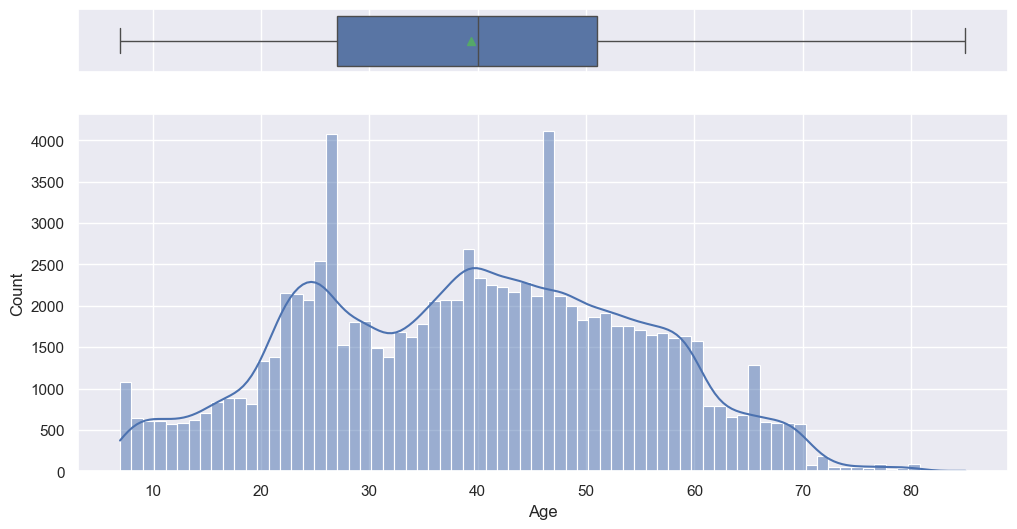

In [38]:
hist_box(data, 'Age')

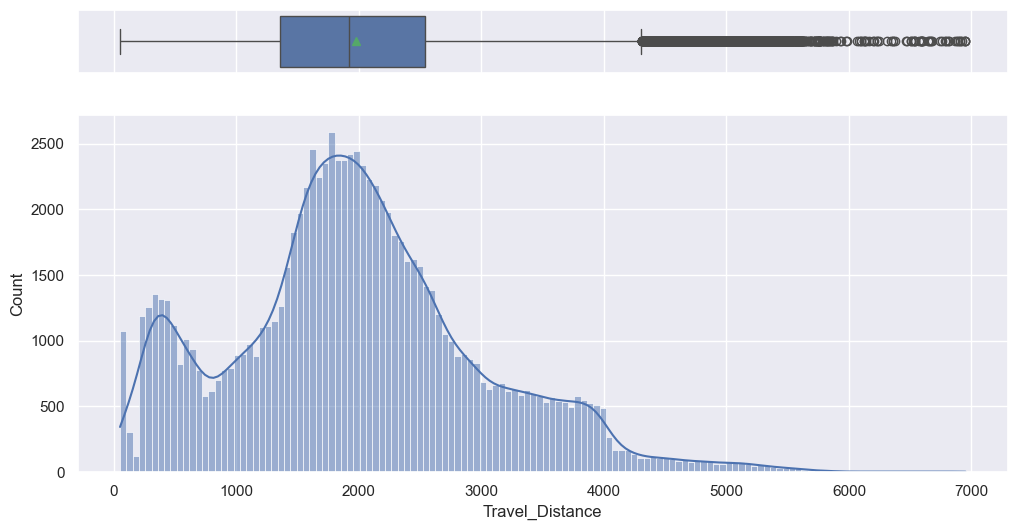

In [39]:
hist_box(data, 'Travel_Distance')

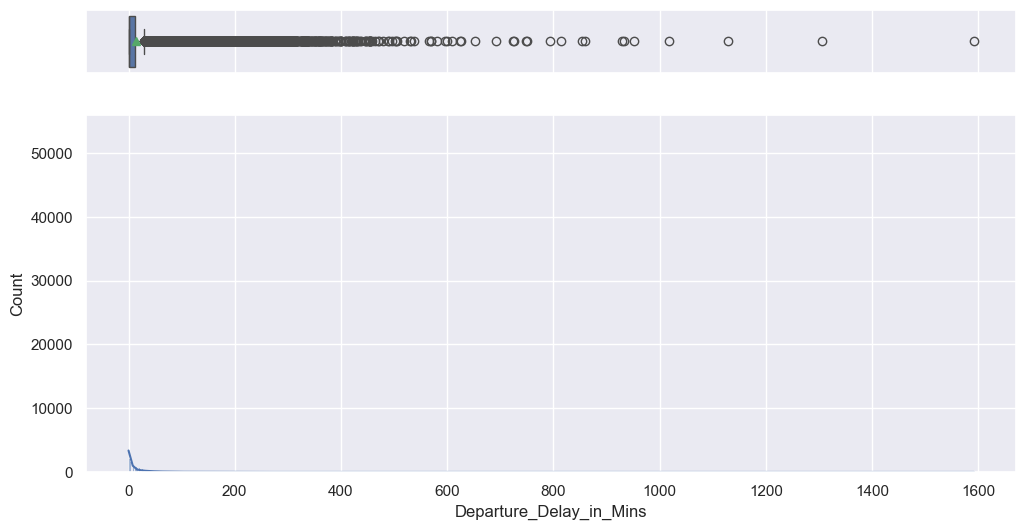

In [40]:
hist_box(data, 'Departure_Delay_in_Mins')

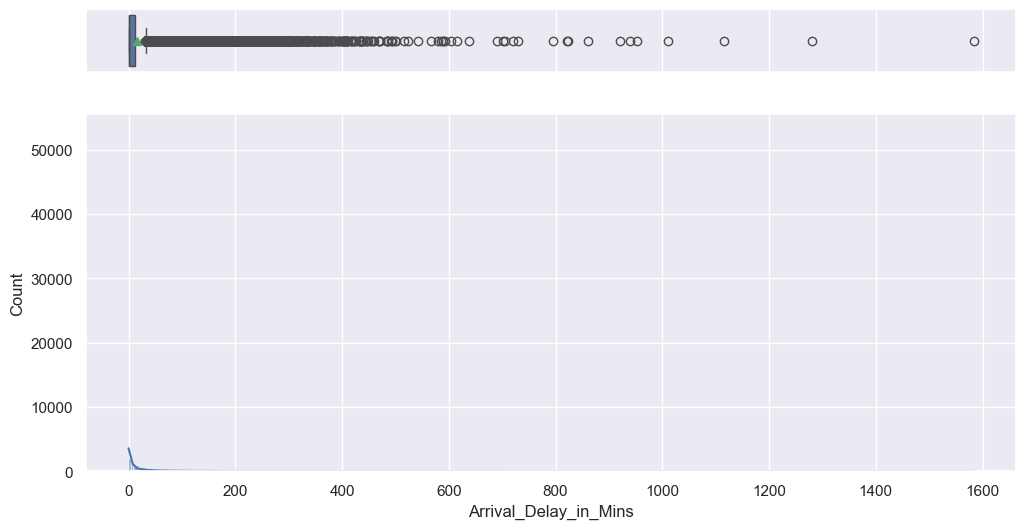

In [41]:
hist_box(data, 'Arrival_Delay_in_Mins')

In [42]:
df = data.copy()

df['Departure_Delay_in_Mins_log'] = np.log1p(df['Departure_Delay_in_Mins'])
df.drop(columns='Departure_Delay_in_Mins', inplace=True)

df['Arrival_Delay_in_Mins_log'] = np.log1p(df['Arrival_Delay_in_Mins'])
df.drop(columns='Arrival_Delay_in_Mins', inplace=True)

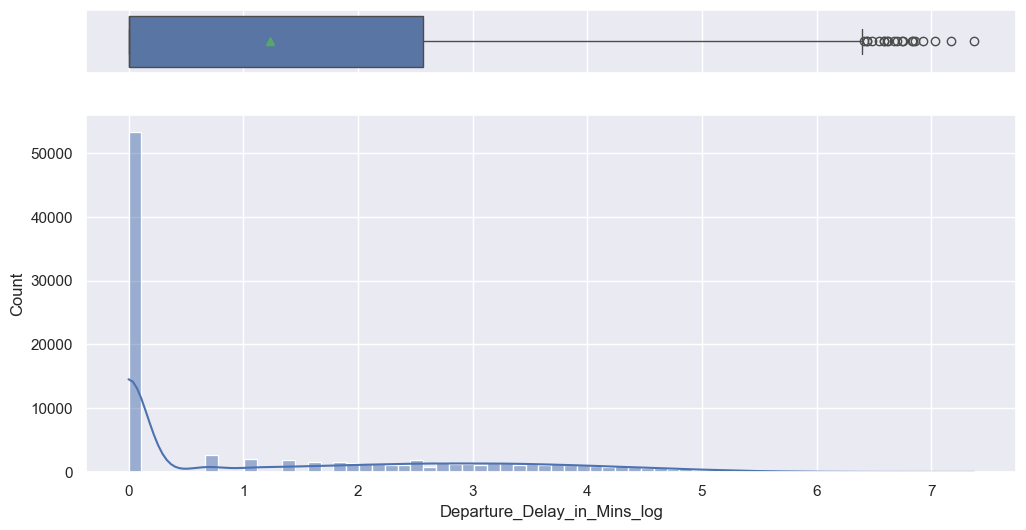

In [43]:
hist_box(df, 'Departure_Delay_in_Mins_log')

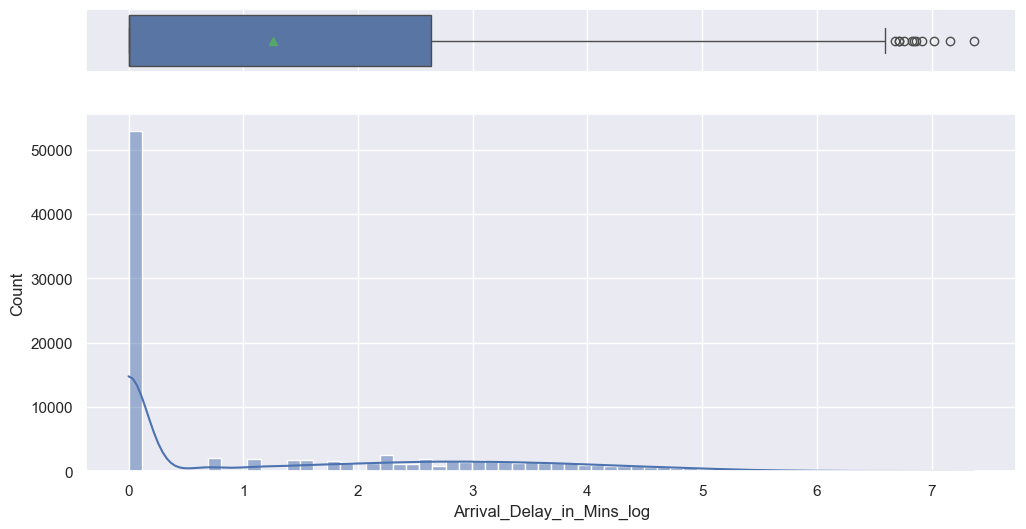

In [44]:
hist_box(df, 'Arrival_Delay_in_Mins_log')

In [45]:
s_test = pd.read_csv('Surveydata_test.csv')
t_test = pd.read_csv('Traveldata_test.csv')

In [46]:
data.columns.to_list()

['ID',
 'Overall_Experience',
 'Seat_Comfort',
 'Seat_Class',
 'Arrival_Time_Convenient',
 'Catering',
 'Platform_Location',
 'Onboard_Wifi_Service',
 'Onboard_Entertainment',
 'Online_Support',
 'Ease_of_Online_Booking',
 'Onboard_Service',
 'Legroom',
 'Baggage_Handling',
 'CheckIn_Service',
 'Cleanliness',
 'Online_Boarding',
 'Gender',
 'Customer_Type',
 'Age',
 'Type_Travel',
 'Travel_Class',
 'Travel_Distance',
 'Departure_Delay_in_Mins',
 'Arrival_Delay_in_Mins']

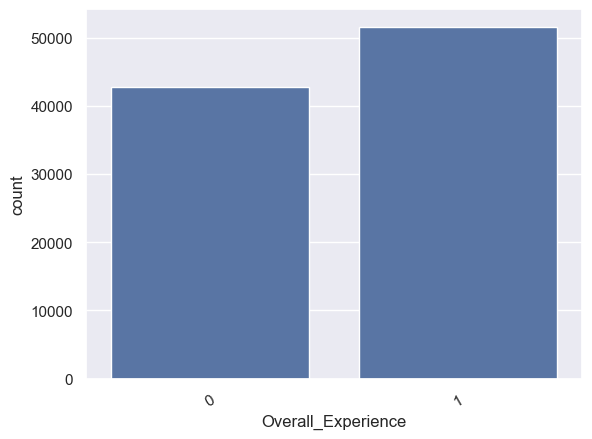

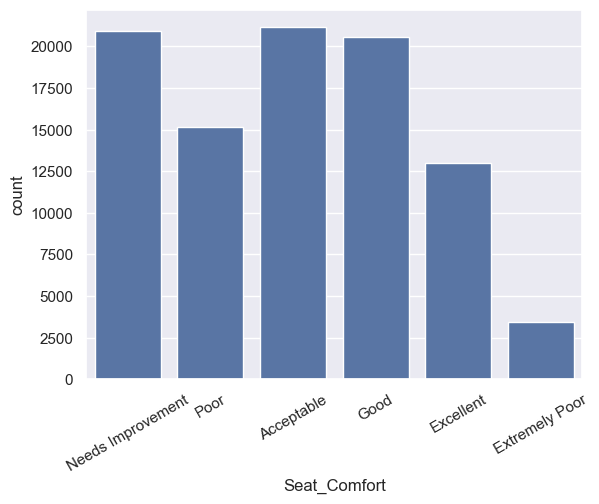

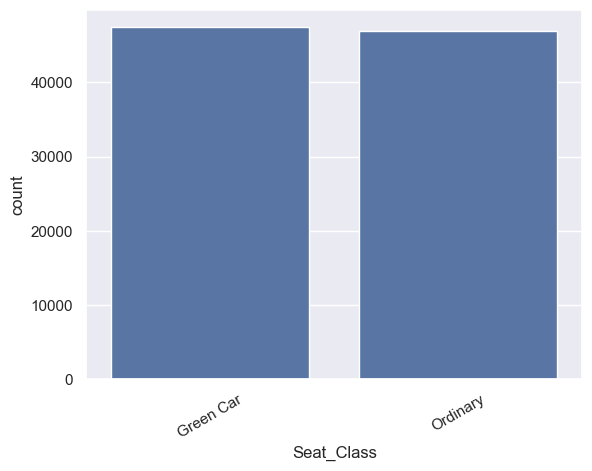

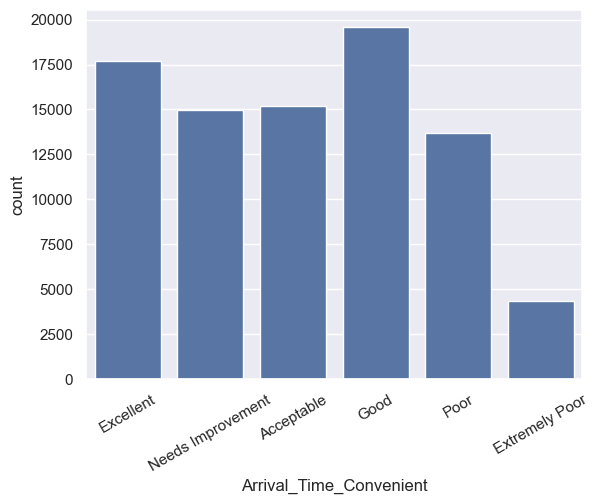

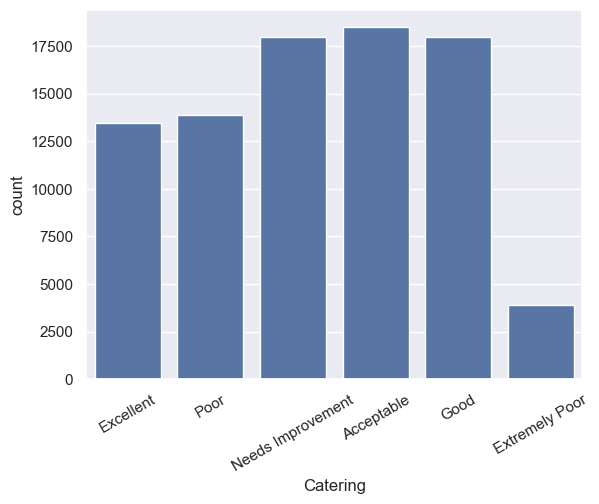

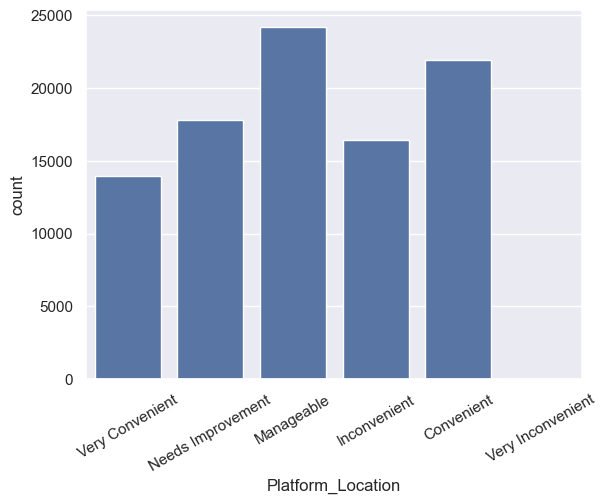

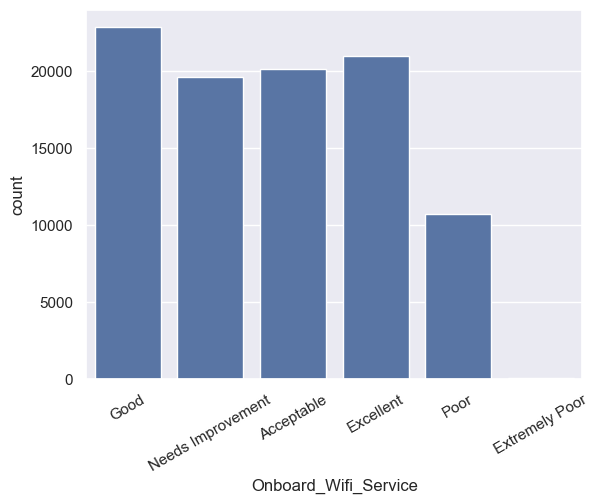

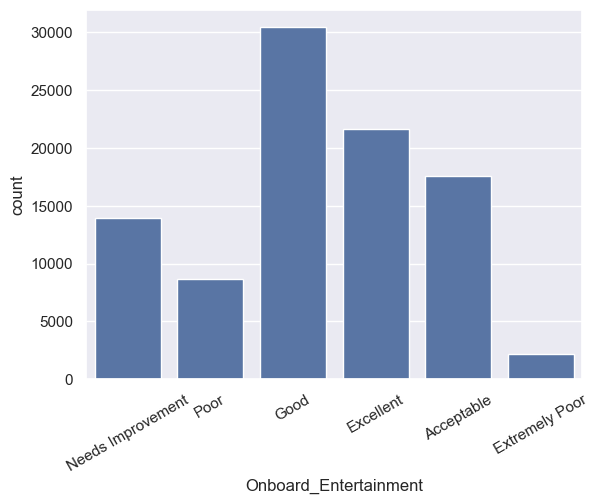

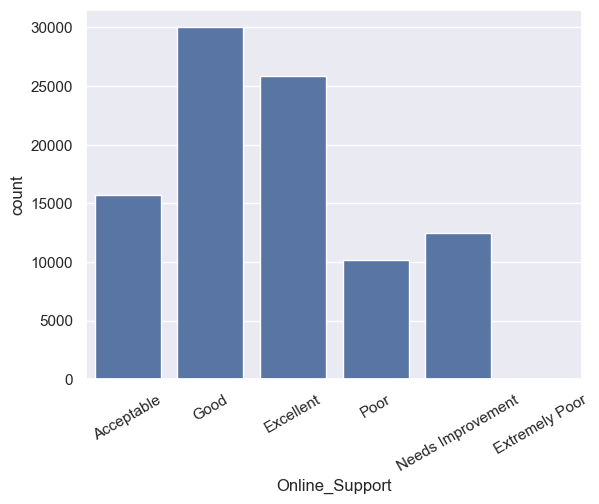

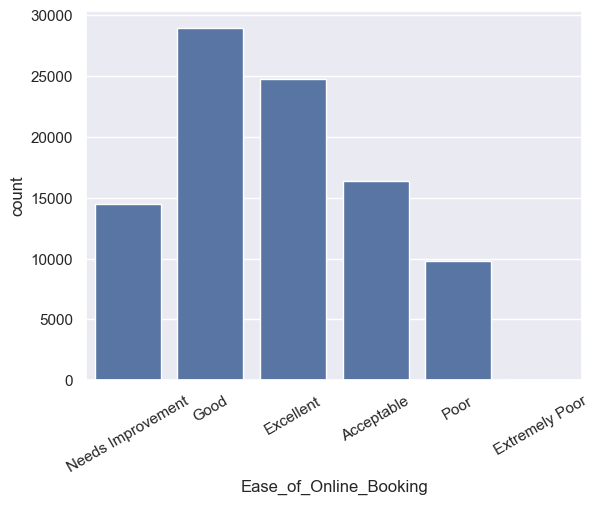

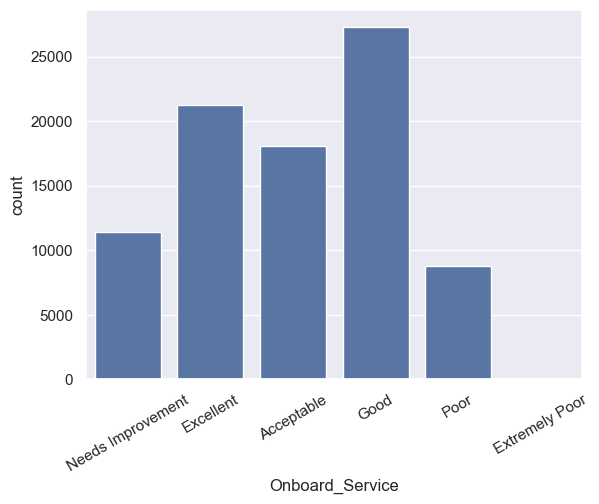

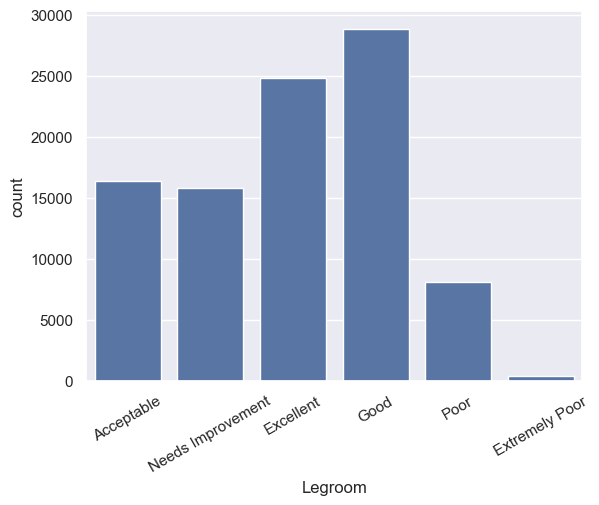

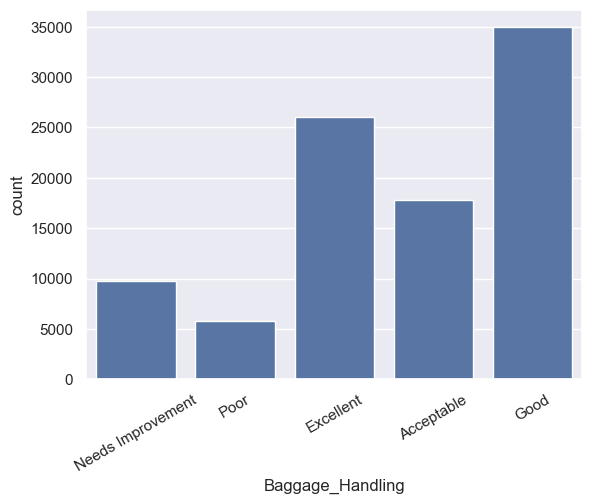

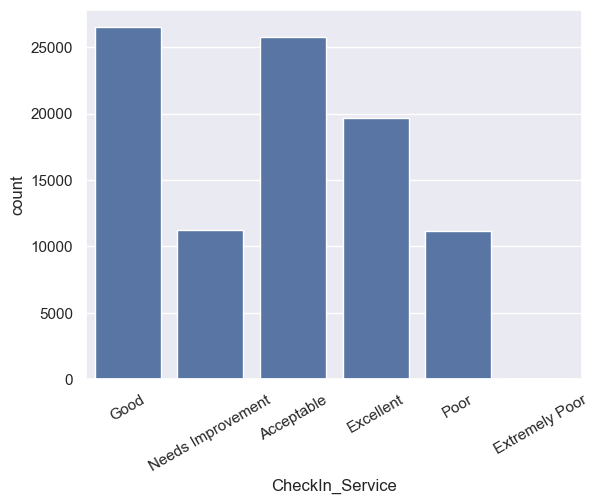

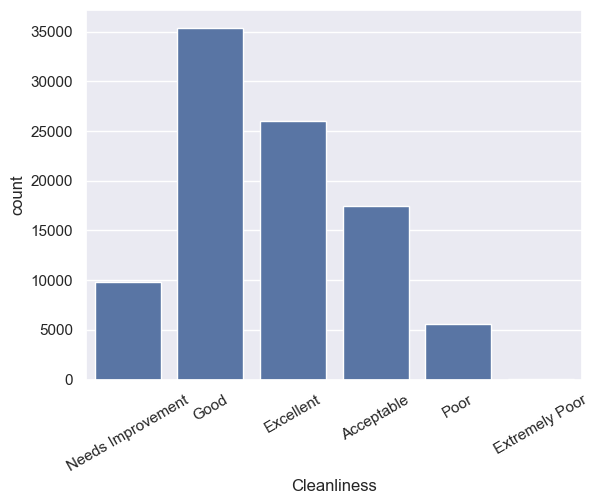

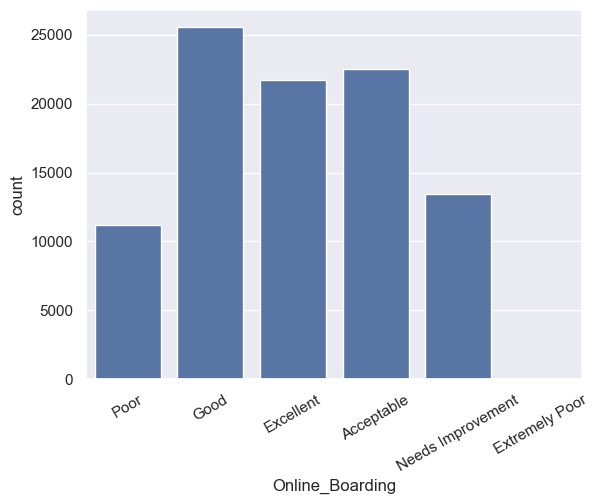

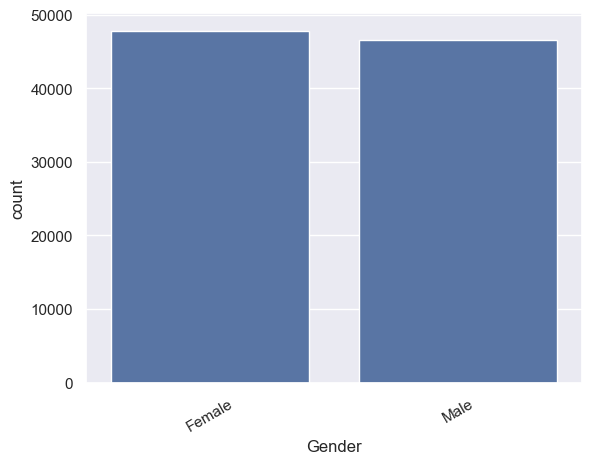

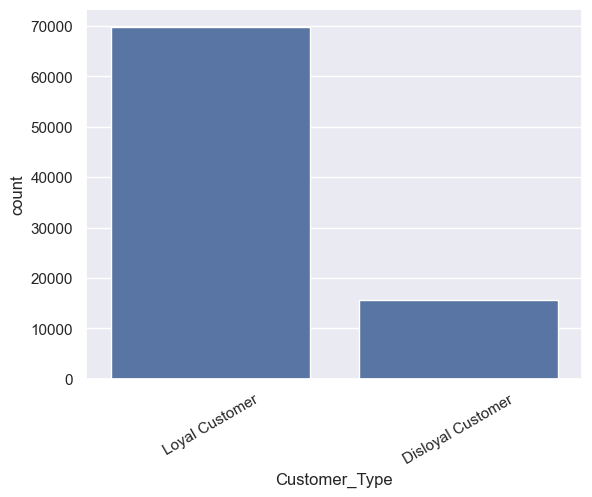

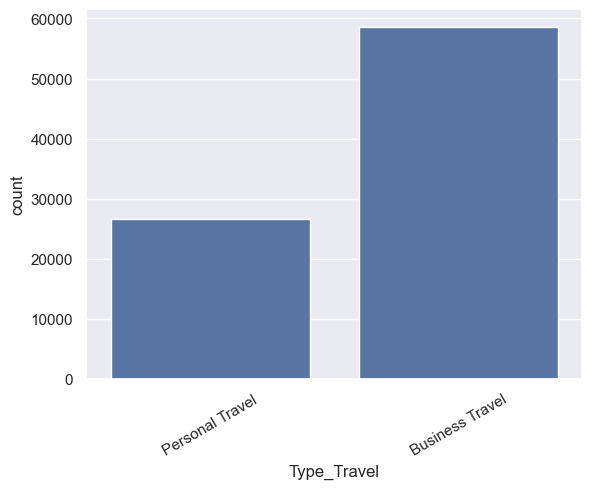

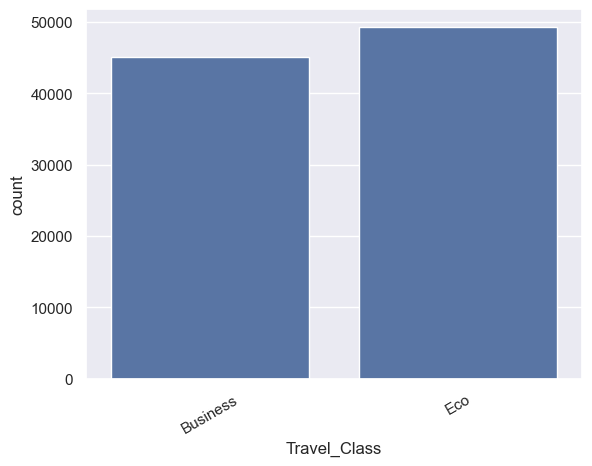

In [48]:
obj_col = [ 'Overall_Experience',
 'Seat_Comfort',
 'Seat_Class',
 'Arrival_Time_Convenient',
 'Catering',
 'Platform_Location',
 'Onboard_Wifi_Service',
 'Onboard_Entertainment',
 'Online_Support',
 'Ease_of_Online_Booking',
 'Onboard_Service',
 'Legroom',
 'Baggage_Handling',
 'CheckIn_Service',
 'Cleanliness',
 'Online_Boarding',
 'Gender',
 'Customer_Type',
  'Type_Travel',
 'Travel_Class'
]

for col in obj_col:
    sns.countplot(x = data[col])
    plt.xticks(rotation=30)
    plt.show()

In [49]:
for col in df.columns:
    if df[col].isnull().any():  # only process columns with missing values
        if pd.api.types.is_numeric_dtype(df[col]):
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
        elif pd.api.types.is_object_dtype(df[col]):
            mode_val = df[col].mode().iloc[0]  # mode() returns a Series
            df[col].fillna(mode_val, inplace=True)


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94379 entries, 0 to 94378
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           94379 non-null  int64  
 1   Overall_Experience           94379 non-null  int64  
 2   Seat_Comfort                 94379 non-null  object 
 3   Seat_Class                   94379 non-null  object 
 4   Arrival_Time_Convenient      94379 non-null  object 
 5   Catering                     94379 non-null  object 
 6   Platform_Location            94379 non-null  object 
 7   Onboard_Wifi_Service         94379 non-null  object 
 8   Onboard_Entertainment        94379 non-null  object 
 9   Online_Support               94379 non-null  object 
 10  Ease_of_Online_Booking       94379 non-null  object 
 11  Onboard_Service              94379 non-null  object 
 12  Legroom                      94379 non-null  object 
 13  Baggage_Handling

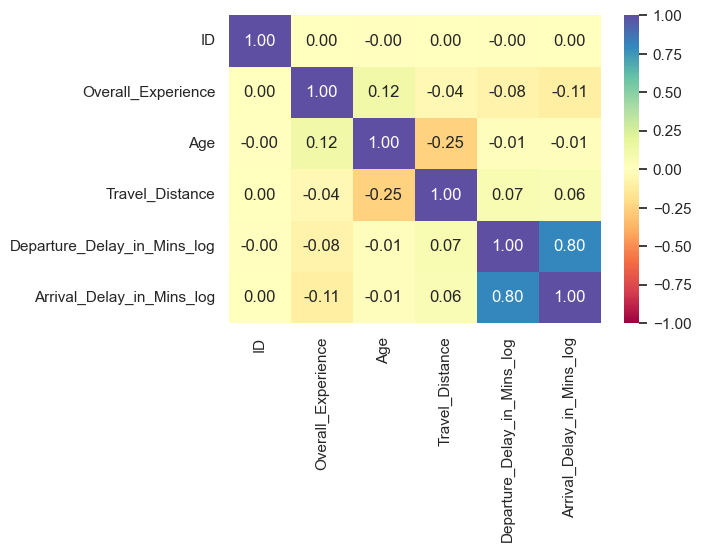

In [51]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(6, 4))
sns.heatmap(df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

In [55]:
# Defining the stacked_barplot() function
def stacked_barplot(data,predictor,target,figsize=(8,5)):
  (pd.crosstab(data[predictor],data[target],normalize='index')*100).plot(kind='bar',figsize=figsize,stacked=True)
  plt.legend(loc="lower right")
  plt.ylabel(target)

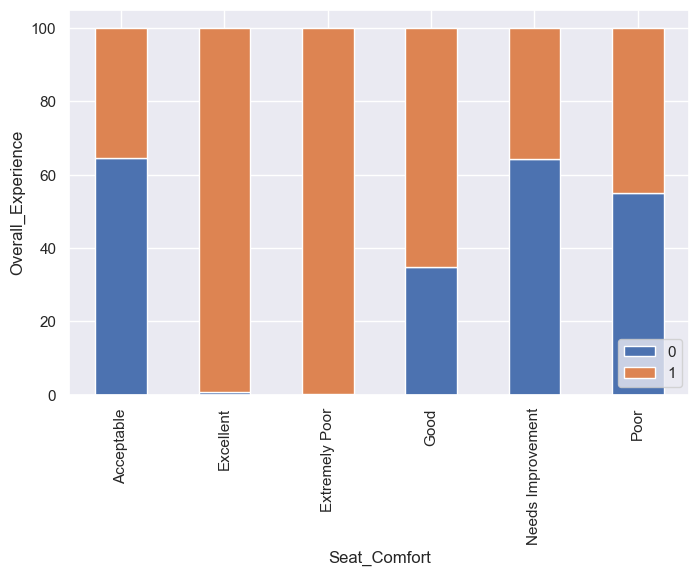

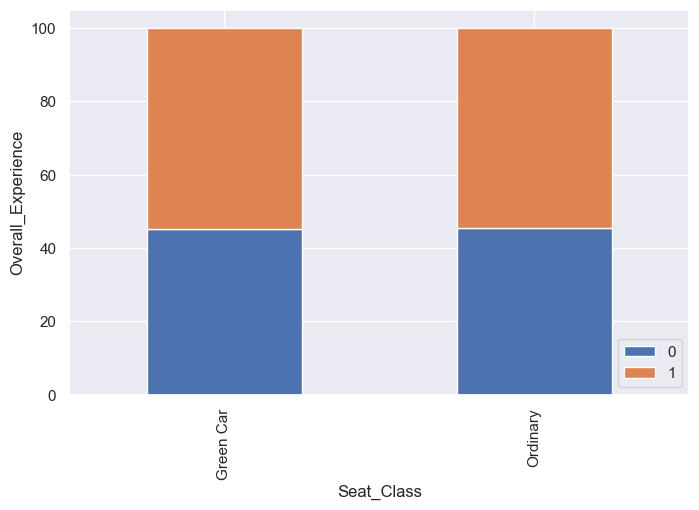

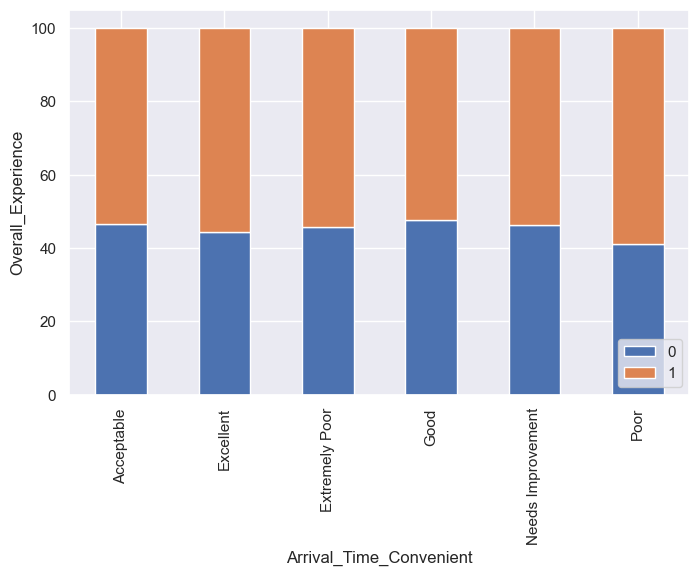

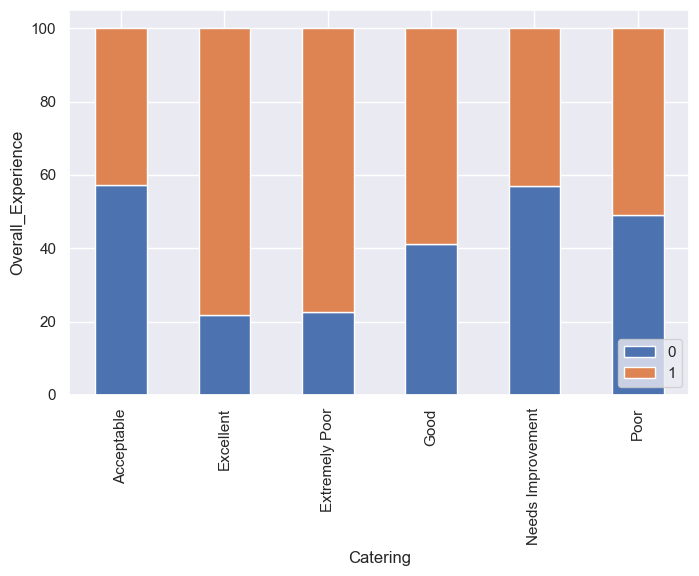

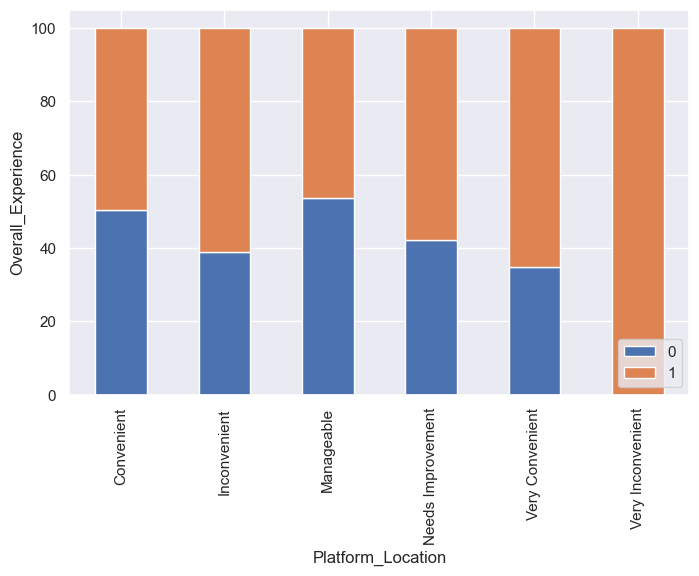

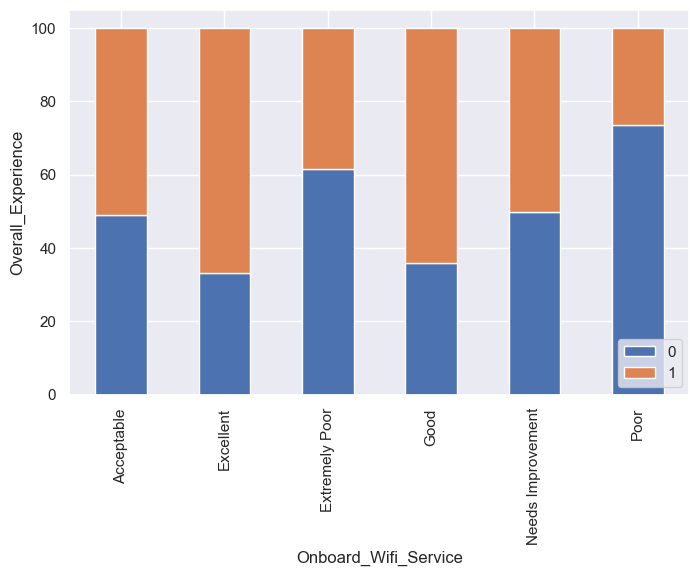

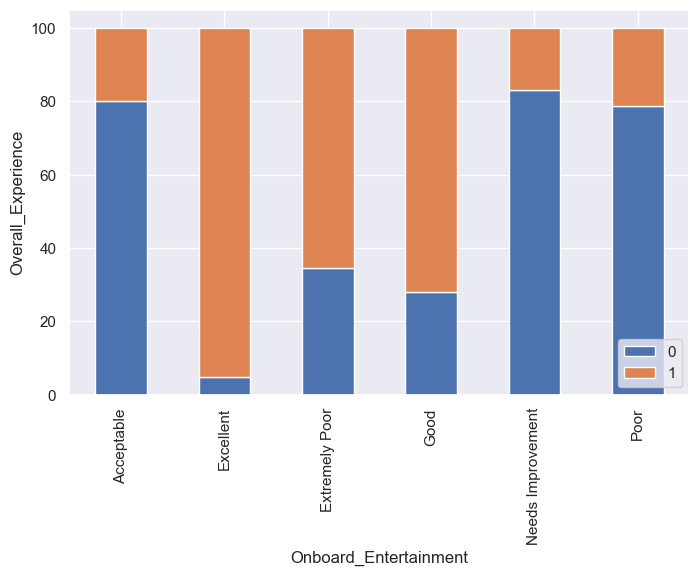

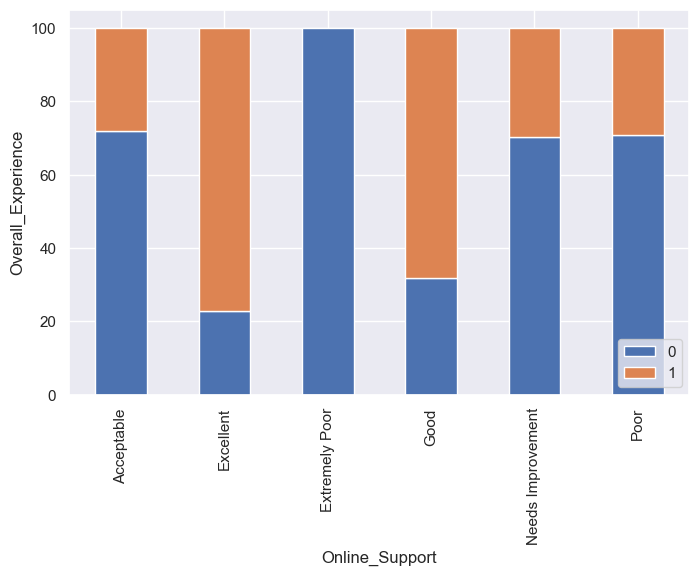

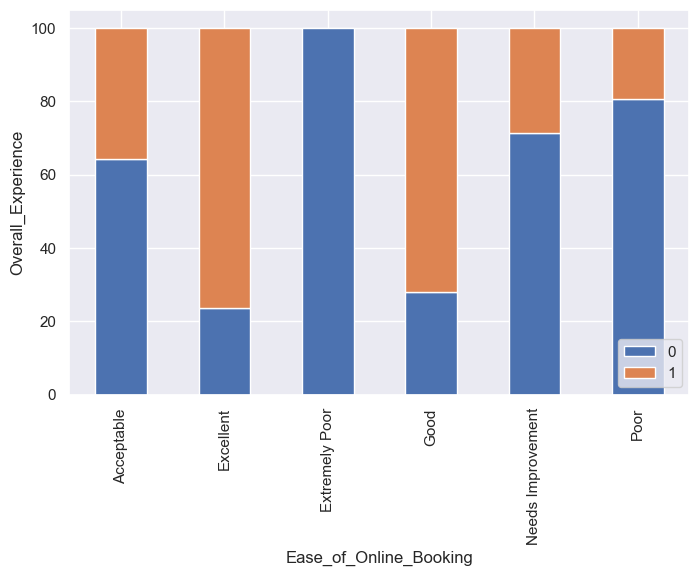

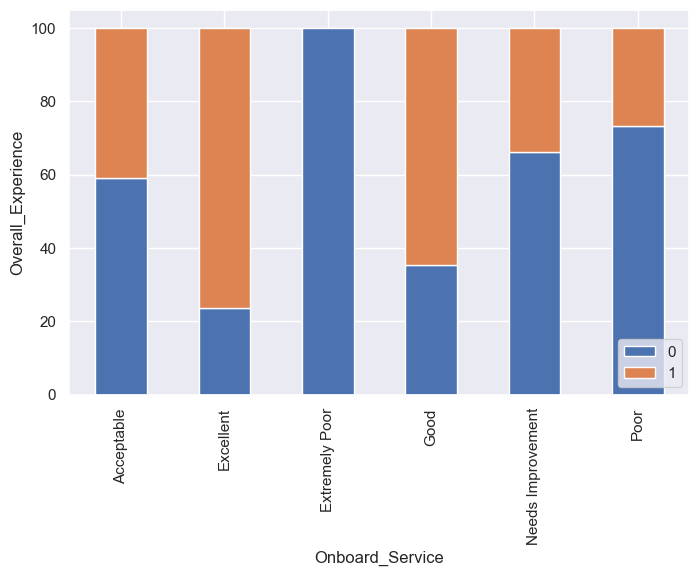

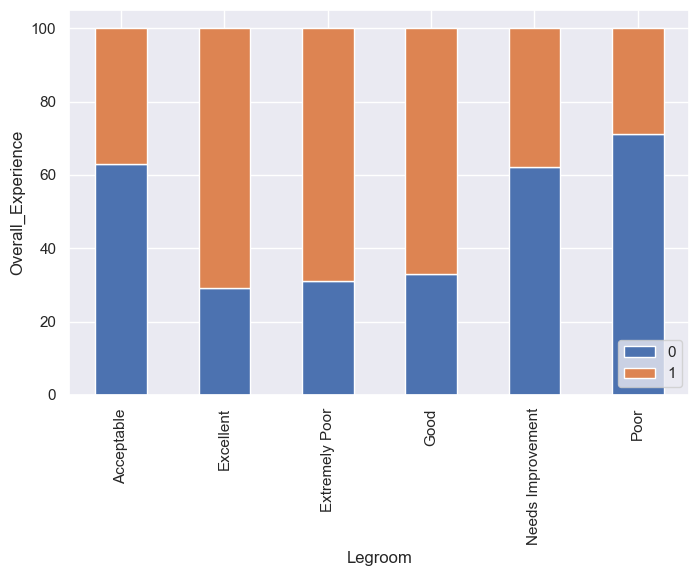

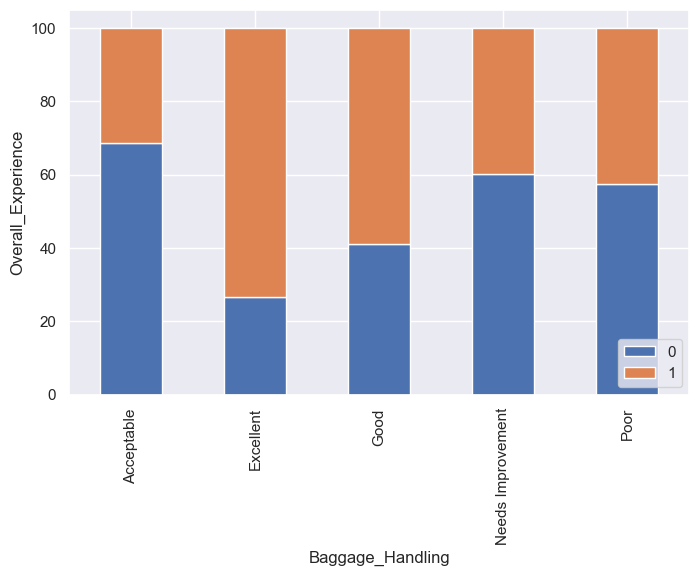

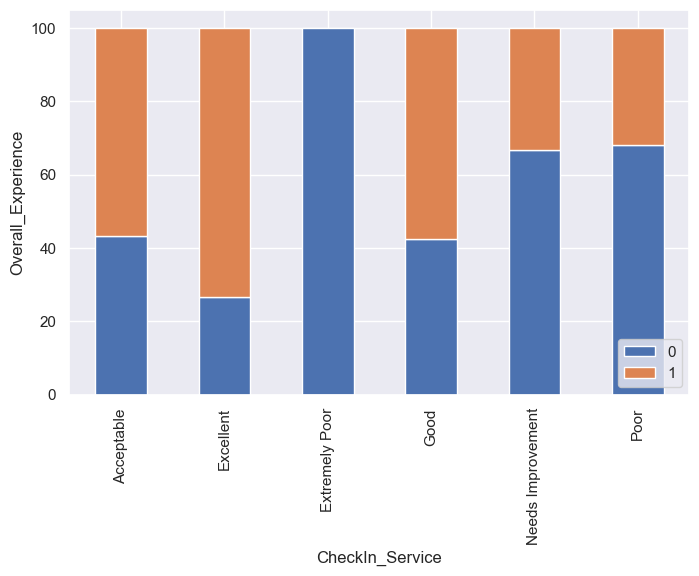

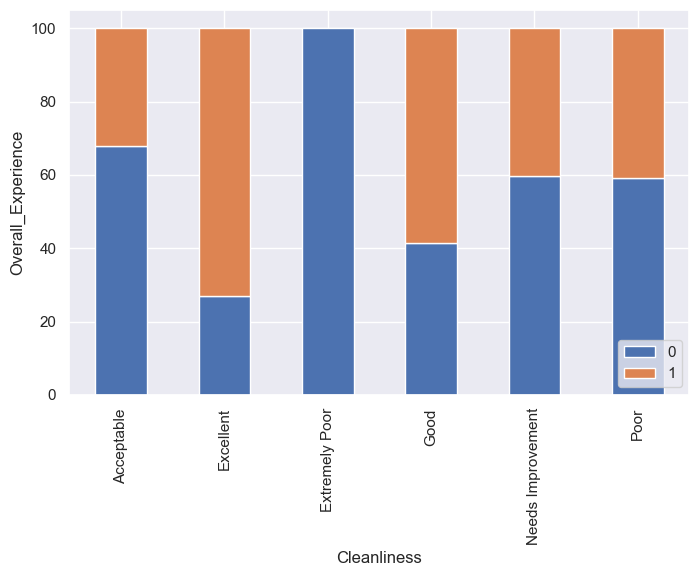

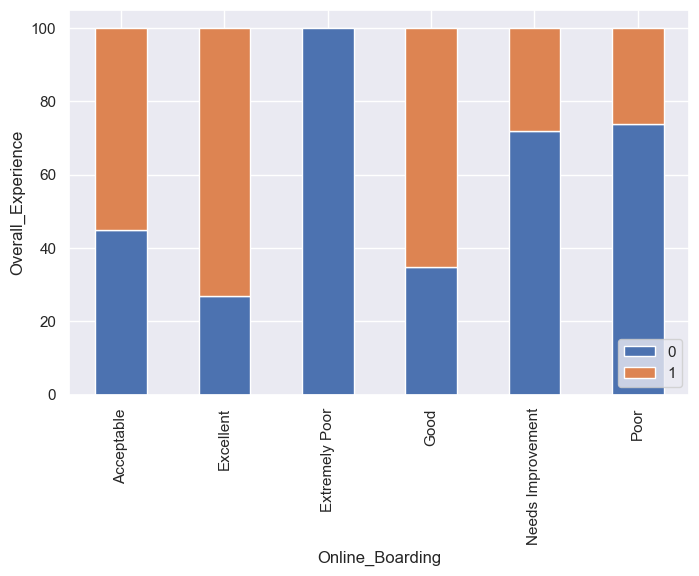

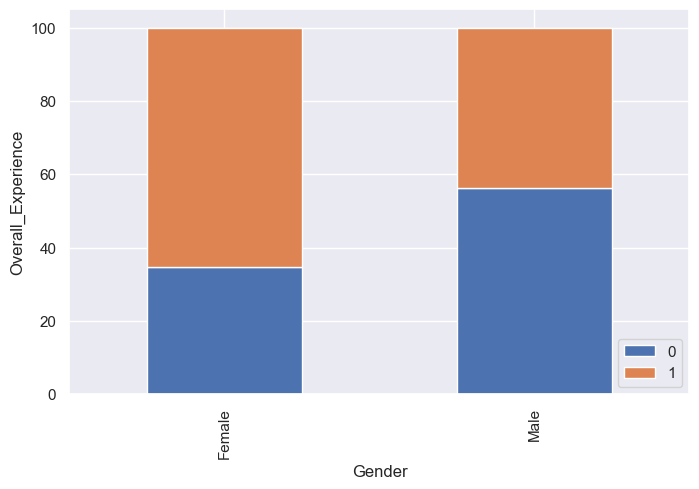

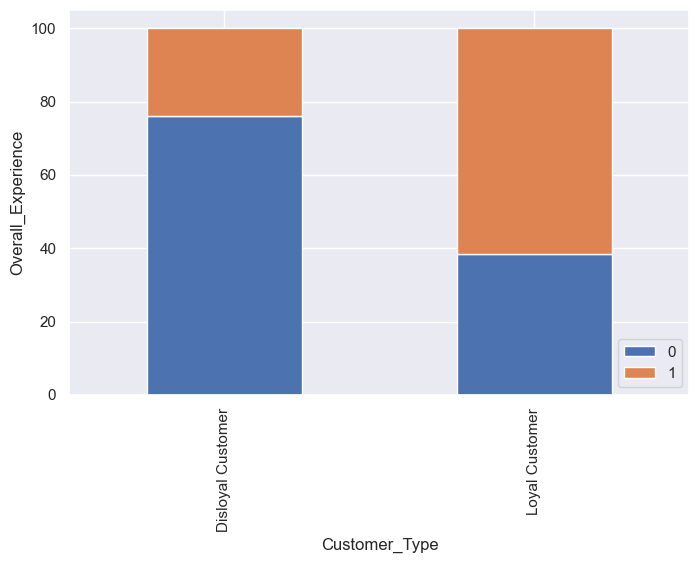

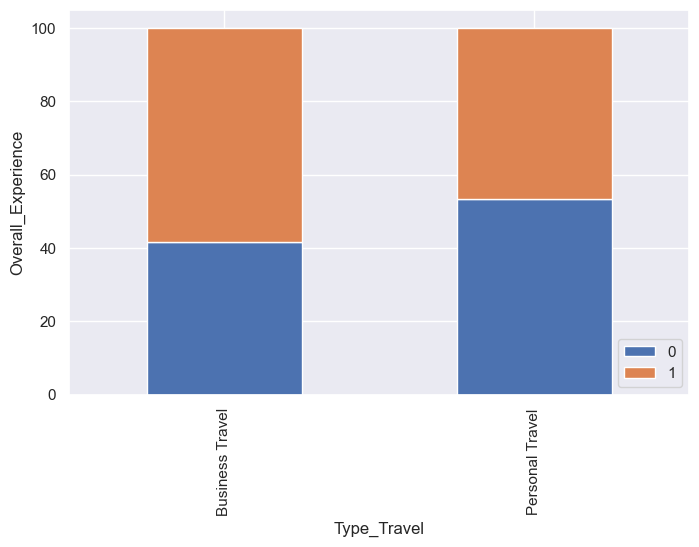

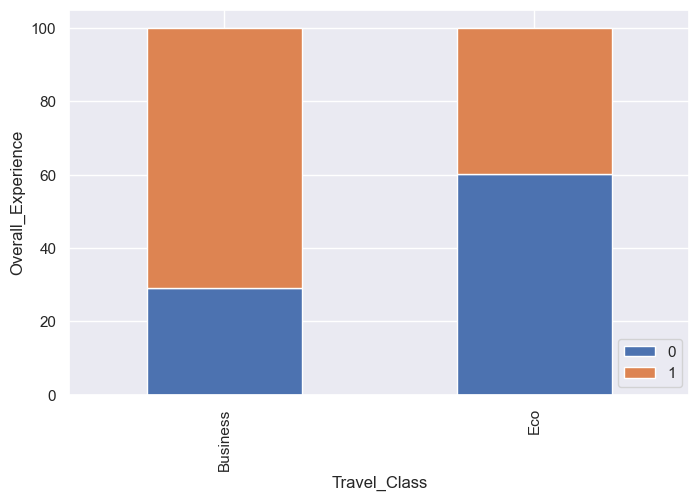

In [56]:
for col in df.columns:
    if pd.api.types.is_object_dtype(df[col]):
        stacked_barplot(data, col, "Overall_Experience" )

In [57]:
# Separating target variable and other variables
X=df.drop(columns=['ID','Overall_Experience'])
Y=df['Overall_Experience']

In [61]:
#Encoding categorical varaibles
for col in df.columns:
    if pd.api.types.is_object_dtype(df[col]):
        print(col)

Seat_Comfort
Seat_Class
Arrival_Time_Convenient
Catering
Platform_Location
Onboard_Wifi_Service
Onboard_Entertainment
Online_Support
Ease_of_Online_Booking
Onboard_Service
Legroom
Baggage_Handling
CheckIn_Service
Cleanliness
Online_Boarding
Gender
Customer_Type
Type_Travel
Travel_Class


In [65]:
obj_col = ['Seat_Comfort', 'Seat_Class', 'Arrival_Time_Convenient', 
           'Catering', 'Platform_Location', 'Onboard_Wifi_Service', 
           'Onboard_Entertainment', 'Online_Support', 'Ease_of_Online_Booking', 
           'Onboard_Service', 'Legroom', 'Baggage_Handling', 
           'CheckIn_Service', 'Cleanliness', 'Online_Boarding', 
           'Gender', 'Customer_Type', 'Type_Travel', 'Travel_Class']

In [66]:
#Encoding categorical varaibles
X=pd.get_dummies(X, columns=obj_col, drop_first=True)

In [67]:
X

,Age,Travel_Distance,Departure_Delay_in_Mins_log,Arrival_Delay_in_Mins_log,Seat_Comfort_Excellent,Seat_Comfort_Extremely Poor,Seat_Comfort_Good,Seat_Comfort_Needs Improvement,Seat_Comfort_Poor,Seat_Class_Ordinary,...,Cleanliness_Poor,Online_Boarding_Excellent,Online_Boarding_Extremely Poor,Online_Boarding_Good,Online_Boarding_Needs Improvement,Online_Boarding_Poor,Gender_Male,Customer_Type_Loyal Customer,Type_Travel_Personal Travel,Travel_Class_Eco
0,52.0,272,0.000000,1.791759,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
1,48.0,2200,2.302585,0.000000,False,False,False,False,True,True,...,False,False,False,True,False,False,True,True,True,True
2,43.0,1061,4.356709,4.787492,False,False,False,True,False,False,...,False,True,False,False,False,False,False,True,False,False
3,44.0,780,2.639057,2.944439,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,50.0,1981,0.000000,0.000000,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94374,32.0,1357,4.430817,4.836282,False,False,False,False,True,True,...,False,False,False,False,False,True,True,True,False,False
94375,44.0,592,1.791759,2.484907,False,False,True,False,False,True,...,False,False,False,True,False,False,True,True,False,False
94376,63.0,2794,0.000000,0.000000,False,False,False,True,False,False,...,False,False,False,False,False,False,True,True,False,False
94377,16.0,2744,0.000000,0.000000,False,False,False,True,False,True,...,False,False,False,True,False,False,True,True,True,True


In [68]:
# Splitting the data into train and test sets
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.10,random_state=1,stratify=Y)

### Decision Tree Model

In [69]:
model_dt = DecisionTreeClassifier(random_state=1)
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [70]:
# Creating metric function 
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))
    
    sns.heatmap(cm, annot=True,  fmt='.2f')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38507
           1       1.00      1.00      1.00     46434

    accuracy                           1.00     84941
   macro avg       1.00      1.00      1.00     84941
weighted avg       1.00      1.00      1.00     84941



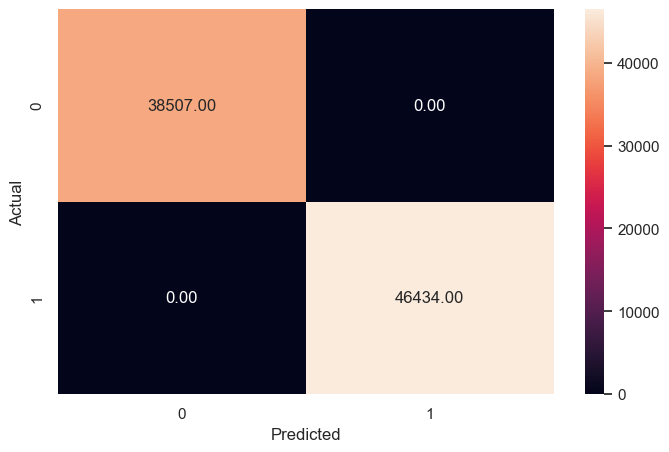

In [71]:
 # Checking performance on the training dataset
pred_train_dt = model_dt.predict(X_train)
metrics_score(y_train, pred_train_dt)

              precision    recall  f1-score   support

           0       0.92      0.91      0.92      4279
           1       0.93      0.93      0.93      5159

    accuracy                           0.92      9438
   macro avg       0.92      0.92      0.92      9438
weighted avg       0.92      0.92      0.92      9438



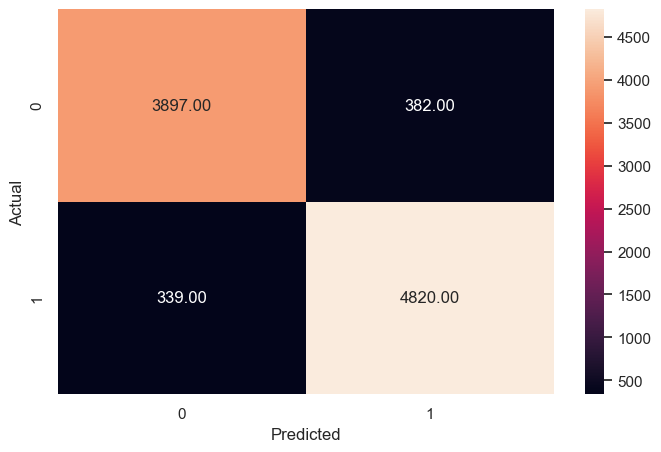

In [72]:
 # Checking performance on the test dataset
pred_test_dt = model_dt.predict(X_test)
metrics_score(y_test, pred_test_dt)

In [78]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    "max_depth": [26], #np.arange(20, 40, 2),
    "max_leaf_nodes": [300, 350, 400],
    "min_samples_split": [40],
}
# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, cv=5,scoring='accuracy',n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=26, max_leaf_nodes=350, min_samples_split=40,
                       random_state=1)

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      4279
           1       0.95      0.93      0.94      5159

    accuracy                           0.94      9438
   macro avg       0.93      0.94      0.93      9438
weighted avg       0.94      0.94      0.94      9438



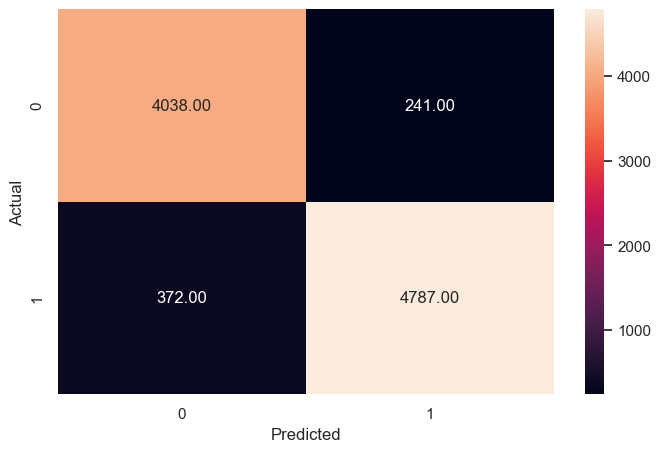

In [79]:
# Checking performance on the test dataset
dt_tuned = estimator.predict(X_test)
metrics_score(y_test,dt_tuned)

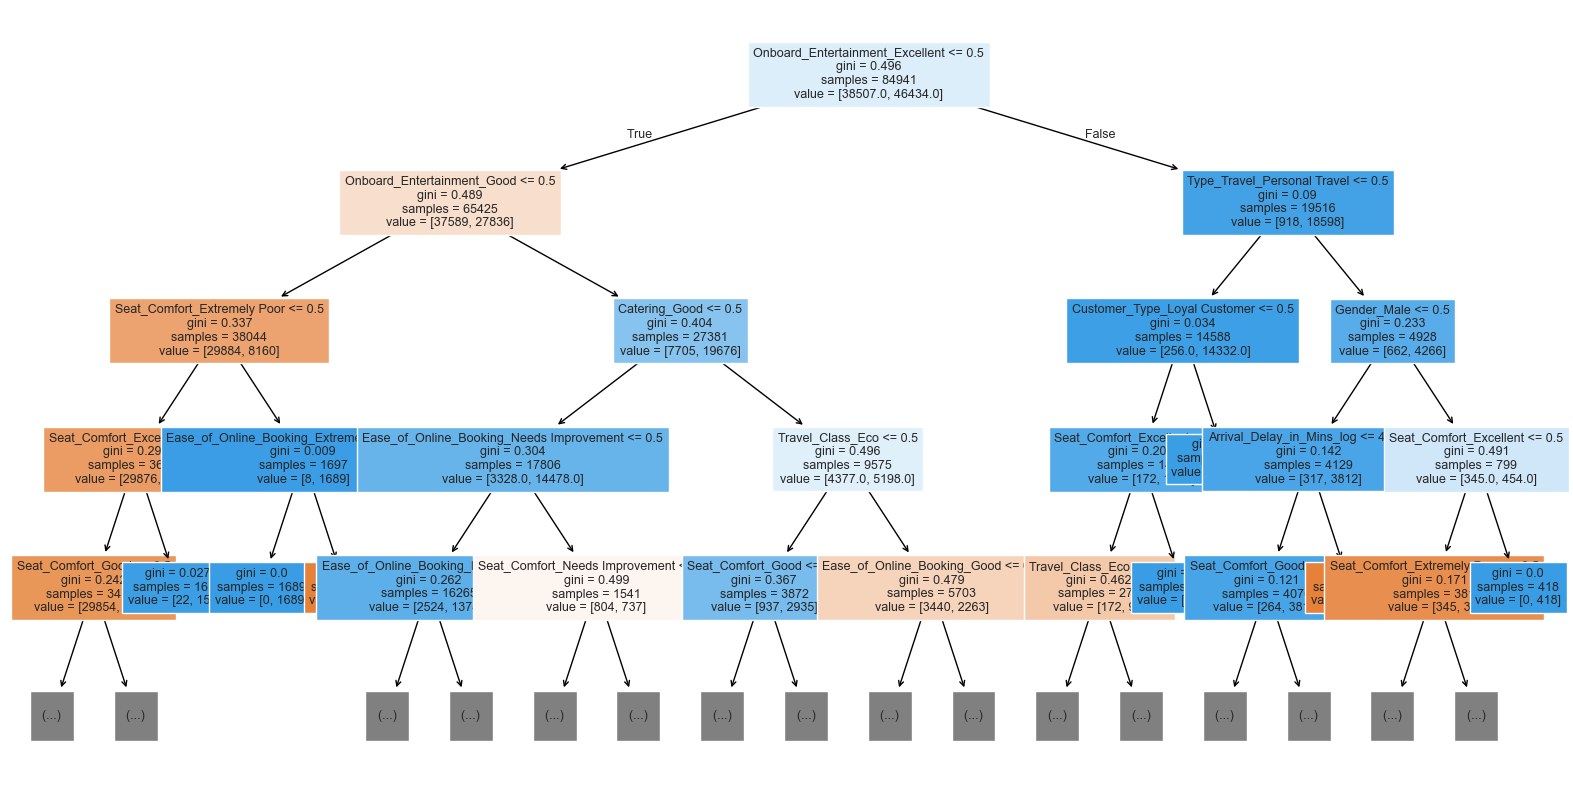

In [80]:
feature_names = list(X_train.columns)
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    estimator,
    max_depth=4,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

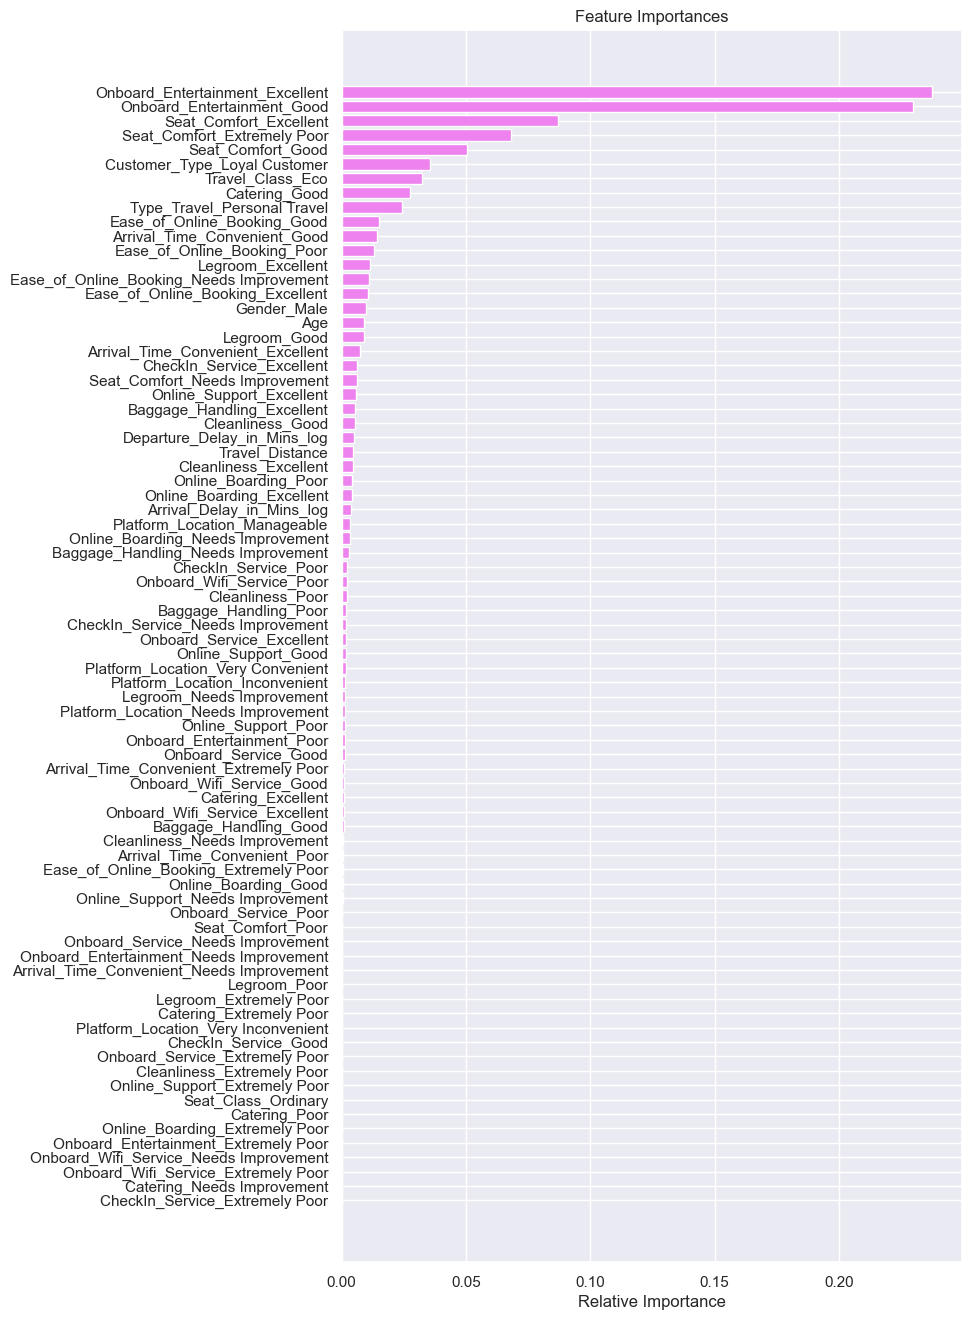

In [82]:
# Importance of features in the tree building
importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 16))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

### Random Forest Model

In [83]:
rf_estimator = RandomForestClassifier( random_state = 1)

rf_estimator.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38507
           1       1.00      1.00      1.00     46434

    accuracy                           1.00     84941
   macro avg       1.00      1.00      1.00     84941
weighted avg       1.00      1.00      1.00     84941



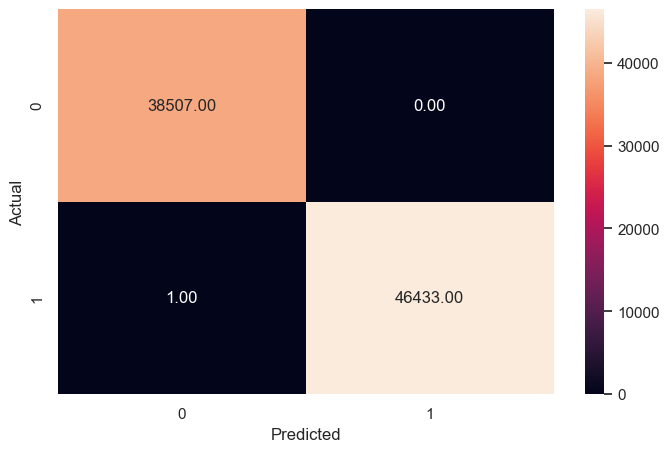

In [84]:
y_pred_train_rf = rf_estimator.predict(X_train)

metrics_score(y_train, y_pred_train_rf)

In [91]:
print("Number of estimators:", rf_estimator.get_params()['n_estimators'])
print("Max depth:", rf_estimator.get_params()['max_depth'])
print("Max features:", rf_estimator.get_params()['max_features'])


Number of estimators: 100
Max depth: None
Max features: sqrt


              precision    recall  f1-score   support

           0       0.93      0.95      0.94      4279
           1       0.96      0.94      0.95      5159

    accuracy                           0.95      9438
   macro avg       0.95      0.95      0.95      9438
weighted avg       0.95      0.95      0.95      9438



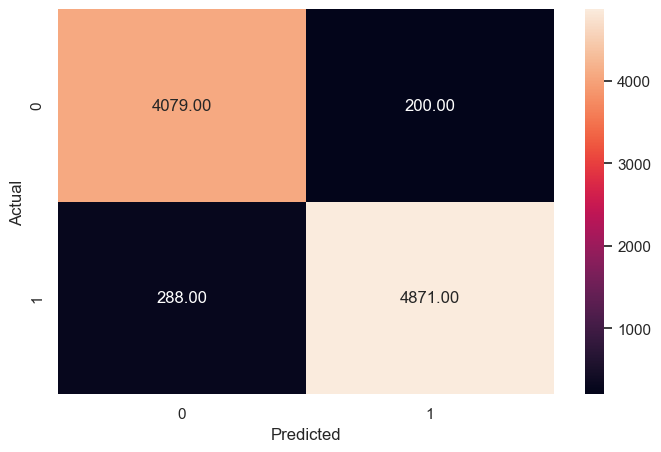

In [85]:
y_pred_test_rf = rf_estimator.predict(X_test)

metrics_score(y_test, y_pred_test_rf)

In [102]:
from xgboost import XGBClassifier

xgb_estimator = XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')
xgb_estimator.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4279
           1       0.96      0.95      0.96      5159

    accuracy                           0.95      9438
   macro avg       0.95      0.95      0.95      9438
weighted avg       0.95      0.95      0.95      9438



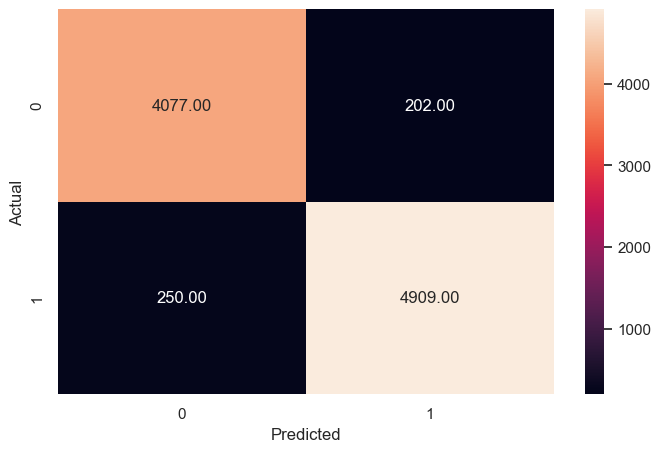

In [103]:
y_pred_test_xgb = xgb_estimator.predict(X_test)
metrics_score(y_test, y_pred_test_xgb)

In [106]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
}

random_search = RandomizedSearchCV(
    estimator=xgb_estimator,
    param_distributions=param_dist,
    n_iter=100,  # number of combinations to try
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=1
)

random_search.fit(X_train, y_train)
print("Best Parameters:", random_search.best_params_)


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'colsample_bytree': 0.8500446374837024, 'learning_rate': 0.1064355485858248, 'max_depth': 9, 'n_estimators': 172, 'subsample': 0.8893459013209253}


              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4279
           1       0.96      0.95      0.96      5159

    accuracy                           0.95      9438
   macro avg       0.95      0.95      0.95      9438
weighted avg       0.95      0.95      0.95      9438



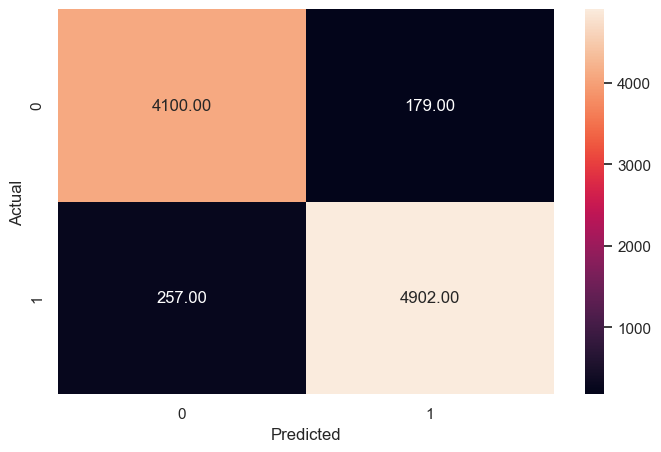

In [108]:
# Best model from search
best_model = random_search.best_estimator_

# Predict on test data
y_pred_test_xgbest = best_model.predict(X_test)
metrics_score(y_test, y_pred_test_xgbest)

### Final XGB:

In [109]:
param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(7, 20),
    'learning_rate': uniform(0.05, 0.25),
    'subsample': uniform(0.75, 0.25),
    'colsample_bytree': uniform(0.7, 0.3),
}

random_search = RandomizedSearchCV(
    estimator=xgb_estimator,
    param_distributions=param_dist,
    n_iter=300,  # number of combinations to try
    cv=8,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=1
)

random_search.fit(X, Y)
print("Best Parameters:", random_search.best_params_)

Fitting 8 folds for each of 300 candidates, totalling 2400 fits
Best Parameters: {'colsample_bytree': 0.7129872814558476, 'learning_rate': 0.17161018579259868, 'max_depth': 16, 'n_estimators': 249, 'subsample': 0.9881184454233148}


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4279
           1       1.00      1.00      1.00      5159

    accuracy                           1.00      9438
   macro avg       1.00      1.00      1.00      9438
weighted avg       1.00      1.00      1.00      9438



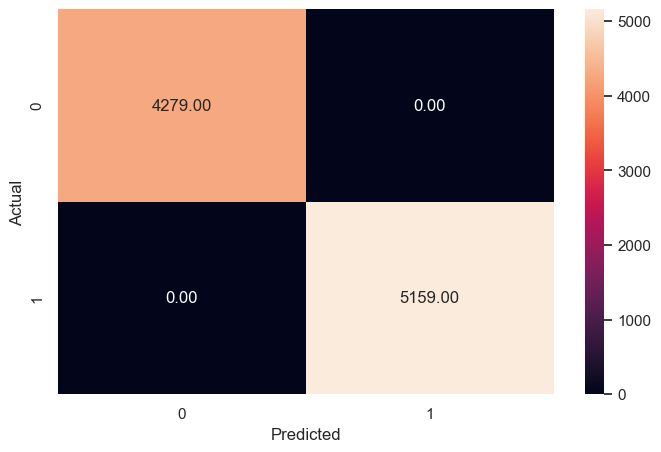

In [110]:
# Best model from search
final_model = random_search.best_estimator_

# Predict on test data
y_pred_test_xgbfinal = final_model.predict(X_test)
metrics_score(y_test, y_pred_test_xgbfinal)

Fitting 8 folds for each of 300 candidates, totalling 2400 fits \
Best Parameters: {'colsample_bytree': 0.7129872814558476, 'learning_rate': 0.17161018579259868, 'max_depth': 16, 'n_estimators': 249, 'subsample': 0.9881184454233148}

### TEST

In [111]:
sd_test = pd.read_csv('Surveydata_test.csv')
td_test = pd.read_csv('Traveldata_test.csv')

In [112]:
data_test = pd.merge(sd_test, td_test, on='ID')

In [113]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35602 entries, 0 to 35601
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       35602 non-null  int64  
 1   Seat_Comfort             35580 non-null  object 
 2   Seat_Class               35602 non-null  object 
 3   Arrival_Time_Convenient  32277 non-null  object 
 4   Catering                 32245 non-null  object 
 5   Platform_Location        35590 non-null  object 
 6   Onboard_Wifi_Service     35590 non-null  object 
 7   Onboard_Entertainment    35594 non-null  object 
 8   Online_Support           35576 non-null  object 
 9   Ease_of_Online_Booking   35584 non-null  object 
 10  Onboard_Service          32730 non-null  object 
 11  Legroom                  35577 non-null  object 
 12  Baggage_Handling         35562 non-null  object 
 13  CheckIn_Service          35580 non-null  object 
 14  Cleanliness           

In [114]:
df_test = data_test.copy()

df_test['Departure_Delay_in_Mins_log'] = np.log1p(df_test['Departure_Delay_in_Mins'])
df_test.drop(columns='Departure_Delay_in_Mins', inplace=True)

df_test['Arrival_Delay_in_Mins_log'] = np.log1p(df_test['Arrival_Delay_in_Mins'])
df_test.drop(columns='Arrival_Delay_in_Mins', inplace=True)

In [115]:
for col in df_test.columns:
    if df_test[col].isnull().any():  # only process columns with missing values
        if pd.api.types.is_numeric_dtype(df_test[col]):
            median_val = df_test[col].median()
            df_test[col].fillna(median_val, inplace=True)
        elif pd.api.types.is_object_dtype(df_test[col]):
            mode_val = df_test[col].mode().iloc[0]  # mode() returns a Series
            df_test[col].fillna(mode_val, inplace=True)


In [116]:
df_test

,ID,Seat_Comfort,Seat_Class,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,...,Cleanliness,Online_Boarding,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins_log,Arrival_Delay_in_Mins_log
0,99900001,Acceptable,Green Car,Acceptable,Acceptable,Manageable,Needs Improvement,Excellent,Good,Excellent,...,Excellent,Poor,Female,Loyal Customer,36.0,Business Travel,Business,532,0.000000,0.000000
1,99900002,Extremely Poor,Ordinary,Good,Poor,Manageable,Acceptable,Poor,Acceptable,Acceptable,...,Excellent,Acceptable,Female,Disloyal Customer,21.0,Business Travel,Business,1425,2.302585,3.367296
2,99900003,Excellent,Ordinary,Excellent,Excellent,Very Convenient,Excellent,Excellent,Excellent,Needs Improvement,...,Needs Improvement,Excellent,Male,Loyal Customer,60.0,Business Travel,Business,2832,0.000000,0.000000
3,99900004,Acceptable,Green Car,Excellent,Acceptable,Very Convenient,Poor,Acceptable,Excellent,Poor,...,Excellent,Poor,Female,Loyal Customer,29.0,Personal Travel,Eco,1352,0.000000,0.000000
4,99900005,Excellent,Ordinary,Extremely Poor,Excellent,Needs Improvement,Excellent,Excellent,Excellent,Excellent,...,Excellent,Excellent,Male,Disloyal Customer,18.0,Business Travel,Business,1610,2.890372,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35597,99935598,Needs Improvement,Green Car,Excellent,Needs Improvement,Manageable,Acceptable,Needs Improvement,Acceptable,Acceptable,...,Good,Acceptable,Male,Loyal Customer,8.0,Personal Travel,Eco,1334,0.000000,0.000000
35598,99935599,Needs Improvement,Ordinary,Needs Improvement,Good,Needs Improvement,Acceptable,Excellent,Excellent,Good,...,Good,Good,Female,Loyal Customer,53.0,Business Travel,Business,1772,0.000000,0.000000
35599,99935600,Good,Green Car,Extremely Poor,Good,Needs Improvement,Needs Improvement,Good,Poor,Needs Improvement,...,Excellent,Needs Improvement,Male,Disloyal Customer,22.0,Business Travel,Eco,1180,0.000000,0.000000
35600,99935601,Excellent,Ordinary,Excellent,Excellent,Inconvenient,Acceptable,Excellent,Good,Excellent,...,Excellent,Good,Female,Loyal Customer,67.0,Personal Travel,Eco,420,3.178054,2.833213


In [145]:
# Separating target variable and other variables
X_test_ = df_test.drop(columns=['ID'])

In [146]:
#Encoding categorical varaibles
for col in df_test.columns:
    if pd.api.types.is_object_dtype(df_test[col]):
        print(col)

Seat_Comfort
Seat_Class
Arrival_Time_Convenient
Catering
Platform_Location
Onboard_Wifi_Service
Onboard_Entertainment
Online_Support
Ease_of_Online_Booking
Onboard_Service
Legroom
Baggage_Handling
CheckIn_Service
Cleanliness
Online_Boarding
Gender
Customer_Type
Type_Travel
Travel_Class


In [147]:
obj_col = ['Seat_Comfort', 'Seat_Class', 'Arrival_Time_Convenient', 
           'Catering', 'Platform_Location', 'Onboard_Wifi_Service', 
           'Onboard_Entertainment', 'Online_Support', 'Ease_of_Online_Booking', 
           'Onboard_Service', 'Legroom', 'Baggage_Handling', 
           'CheckIn_Service', 'Cleanliness', 'Online_Boarding', 
           'Gender', 'Customer_Type', 'Type_Travel', 'Travel_Class']

In [148]:
#Encoding categorical varaibles
X_test_ = pd.get_dummies(X_test_, columns=obj_col)

In [149]:
# Get the columns to keep and to add
columns_to_keep = X_test.columns.intersection(X_test_.columns)
columns_to_add = X_test.columns.difference(X_test_.columns)

# Keep only the relevant columns
X_test_ = X_test_[columns_to_keep].copy()

# Add missing columns filled with False
for col in columns_to_add:
    X_test_[col] = False

# Reorder columns to match X_test exactly
X_test_ = X_test_[X_test.columns]

In [150]:
# Predict on test data
y_pred_test_xgbfinal_ = final_model.predict(X_test_)

In [153]:
# Create a new DataFrame with ID and predictions
results_df = pd.DataFrame({
    'ID': df_test['ID'].values,
    'Overall_Experience': y_pred_test_xgbfinal_
})

In [154]:
results_df.to_csv('Fantasia-predictions.csv', index=False)